# Module C Milestone 1: Data Science Capstone
## Week 5 — Support Vector Machine (SVM) & Kernel Methods

**Learning Objectives:**
1. Describe how a support vector machine creates a decision boundary and how the margin relates to classification performance.
2. Identify the role of support vectors and explain how they determine the position of the decision boundary.
3. Use different kernel functions (linear, polynomial, Gaussian/RBF) to apply the kernel trick and transform data for better classification.
4. Adjust the regularization parameter `C` in SVMs to balance margin size and classification accuracy on the training data.

**Datasets**: Fraud Detection (deep dive), Credit Approval, Loan Default  
**Primary Metric**: AUC-ROC  
**Note**: SVM training is O(N²) due to the Gram matrix; a stratified 20K sample is used for the fraud dataset.

In [1]:
# ===========================================================================
# ALL IMPORTS
# ===========================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, recall_score, precision_recall_curve)

warnings.filterwarnings('ignore')

DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

SVM_SAMPLE_F   = 20_000   # Fraud — consistent with prior weeks for model comparison
SVM_SAMPLE_MAX = 30_000   # Credit / Loan cap

C_LINEAR = [0.01, 0.1, 1.0, 10.0, 100.0]
C_POLY   = [0.1, 1.0, 10.0]
DEGREES  = [2, 3, 4]
C_RBF    = [0.1, 1.0, 10.0, 100.0]
GAMMAS   = ['scale', 0.01, 0.1]
C_range  = [0.01, 0.1, 1.0, 10.0, 100.0]

# Best test AUC per dataset per week — same test set throughout (comparable)
PRIOR_AUC = {
    'Fraud':  [('Wk1_IntTerm_LR', 0.9820), ('Wk2_Lasso',    0.9817),
               ('Wk3_Backward*',  0.9378), ('Wk4_Fwd_LR',   0.9591)],
    'Credit': [('Wk1_IntTerm_LR', 0.9990), ('Wk2_Ridge',    0.9993),
               ('Wk3_Backward*',  0.9874), ('Wk4_Fwd_LR',   0.9991)],
    'Loan':   [('Wk1_IntTerm_LR', 0.6816), ('Wk2_Ridge',    0.6832),
               ('Wk3_Forward*',   0.6810), ('Wk4_Fwd_LR',   0.6861)],
}

_orig_write = sys.stdout.write
sys.stdout.write = lambda s: _orig_write(s.replace('\x07', '').replace('\x08', ''))

print('Week 5 workspace initialized.')

Week 5 workspace initialized.


In [2]:
# ===========================================================================
# HELPER FUNCTIONS — SVM kernel search variants
# probability=False + decision_function avoids Platt scaling (6× speedup)
# probability=True reserved for final single evaluation only
# ===========================================================================

def linear_svm_search(X_train, X_test, y_train, y_test, C_values, class_weight='balanced'):
    """Search over C values for linear-kernel SVM."""
    X_train = np.asarray(X_train); X_test = np.asarray(X_test)
    results = []
    for C in C_values:
        clf = SVC(kernel='linear', C=C, class_weight=class_weight,
                  probability=False, random_state=42, cache_size=1000, max_iter=2000)
        clf.fit(X_train, y_train)
        auc  = roc_auc_score(y_test, clf.decision_function(X_test))
        n_sv = clf.n_support_.sum()
        results.append({'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
        print(f'  [Linear  C={C:.4f}]  AUC={auc:.4f}  SV={n_sv:,}')
    return pd.DataFrame(results)


def poly_svm_search(X_train, X_test, y_train, y_test, C_values, degrees, class_weight='balanced'):
    """Search over degree and C for polynomial-kernel SVM."""
    X_train = np.asarray(X_train); X_test = np.asarray(X_test)
    results = []
    for d in degrees:
        for C in C_values:
            clf = SVC(kernel='poly', C=C, degree=d, coef0=1, gamma='scale',
                      class_weight=class_weight, probability=False, random_state=42, cache_size=1000, max_iter=2000)
            clf.fit(X_train, y_train)
            auc  = roc_auc_score(y_test, clf.decision_function(X_test))
            n_sv = clf.n_support_.sum()
            results.append({'degree': d, 'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
            print(f'  [Poly  d={d}  C={C:.3f}]  AUC={auc:.4f}  SV={n_sv:,}')
    return pd.DataFrame(results)


def rbf_svm_search(X_train, X_test, y_train, y_test, C_values, gammas, class_weight='balanced'):
    """Search over C and gamma for RBF-kernel SVM."""
    X_train = np.asarray(X_train); X_test = np.asarray(X_test)
    results = []
    for gamma in gammas:
        for C in C_values:
            clf = SVC(kernel='rbf', C=C, gamma=gamma,
                      class_weight=class_weight, probability=False, random_state=42, cache_size=1000, max_iter=2000)
            clf.fit(X_train, y_train)
            auc  = roc_auc_score(y_test, clf.decision_function(X_test))
            n_sv = clf.n_support_.sum()
            results.append({'gamma': str(gamma), 'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
            print(f'  [RBF  gamma={gamma}  C={C:.3f}]  AUC={auc:.4f}  SV={n_sv:,}')
    return pd.DataFrame(results)


def _resolve_gamma(gamma_str):
    """Convert gamma string back to float if not 'scale'/'auto'."""
    if gamma_str in ('scale', 'auto'):
        return gamma_str
    return float(gamma_str)


print('Helper functions defined.')

Helper functions defined.


---
# Section 1: Fraud Detection Dataset (Deep Dive)

Week 5 applies three SVM kernels (linear, polynomial, RBF) to each dataset.
The Fraud dataset is the deep-dive focus: each kernel is analyzed in detail,
and the regularization parameter `C` is examined across a wide range to show
the bias–variance trade-off (large `C` = hard margin = fewer SVs; small `C` = soft margin = more SVs).

**Why StandardScaling is mandatory for SVM**: SVM optimizes the margin using
Euclidean distance in feature space. Without scaling, features with large numeric
ranges (e.g., `amt` in dollars) dominate the margin calculation, biasing the
decision boundary. StandardScaling ensures all features contribute equally.

**Sampling rationale**: The Gram matrix for N samples has N² entries.
At 1.3M training rows, storing the Gram matrix would require ≈10 TB of RAM.
A stratified 20K sample is used throughout the fraud analysis.

**Actual result (Wk5 SVM): AUC = 0.9457** — The 20K sample constraint (1.5% of
training data) is the primary limiting factor. Week 1 (AUC = 0.9820, trained on
the full dataset with `amt × category` interaction features) remains the best
model for fraud detection across all five weeks. This is a structural limitation
of SVM on large datasets, not a reflection of SVM's theoretical capability.

### Analytical Approach

**Kernel selection strategy**
- **Linear kernel** (`kernel='linear'`): Finds the maximum-margin hyperplane
  directly in the original feature space. Best when data is approximately
  linearly separable. Decision weights `w` are directly interpretable.
- **Polynomial kernel** (`kernel='poly'`, `coef0=1`): Maps data to a higher-dimensional
  polynomial feature space via the kernel trick, allowing curved decision boundaries
  without explicitly computing the expanded feature vectors.
- **RBF/Gaussian kernel** (`kernel='rbf'`): Projects data into infinite-dimensional
  Hilbert space; most flexible boundary shape. Controlled by `gamma` (bandwidth):
  small γ = smooth decision surface; large γ = tight fit around each training point.

**Regularization (`C`)**: Controls the soft-margin trade-off.
- Small `C`: wide margin, more misclassifications tolerated (low variance, higher bias).
  As `C` decreases, more training points fall inside or across the margin — the number
  of support vectors increases.
- Large `C`: narrow margin, fewer misclassifications tolerated (high variance, lower bias).
  Fewer support vectors; the boundary hugs the training data more tightly.
- Section [7/9] sweeps `C` across `[0.01, 0.1, 1.0, 10.0, 100.0]` with the best kernel
  and plots AUC vs. support vector count (Figures 5, 11, 17), showing this trade-off
  empirically. A flat AUC plateau with rapidly falling SV count indicates the model
  has found a stable margin; a drop in AUC at large `C` signals overfitting.

**Class imbalance — `class_weight='balanced'`**: At a ~1–2% fraud rate, a naive SVM
maximizes the margin for the dominant class (legitimate transactions) and nearly ignores
fraud. Setting `class_weight='balanced'` re-weights each class by the inverse of its
frequency: with ~1% fraud, every misclassified fraud transaction is penalized
approximately **99× more** than a misclassified legitimate transaction in the SVM loss.
This forces the decision boundary to shift toward the legitimate class, recovering
meaningful recall on the minority class at the cost of increased false positives.
Without this setting, the SVM would achieve near-zero recall on fraud regardless of
kernel or `C`.

**Threshold selection**: After refitting with `probability=True` (Platt scaling), the
model outputs a calibrated fraud probability per transaction. The default threshold of
0.5 is inappropriate under class imbalance — with a ~1–2% fraud rate the model rarely
assigns probability > 0.5 to any transaction, yielding near-zero recall. Instead, the
F1-maximizing threshold is found by evaluating F1 at every precision-recall operating
point and selecting the threshold where F1 peaks. For the fraud dataset this yields
**threshold ≈ 0.1487**: any transaction the model estimates as more than ~15% likely to
be fraud is flagged. This threshold is determined from the test set labels for analysis
purposes only — in production, it would be calibrated on a held-out validation set to
avoid data leakage.

In [3]:
print('=' * 65)
print('FRAUD [1/9] Load & Preprocessing')
print('=' * 65)

fraud_train = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')
TARGET_F   = 'is_fraud'
POLY_COL_F = 'amt'
CAT_COLS_F = ['category', 'gender']

old_dummies = [c for c in fraud_train.columns
               if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
if old_dummies:
    fraud_train.drop(columns=old_dummies, inplace=True)
    fraud_test.drop(columns=old_dummies, inplace=True)

for c in fraud_train.select_dtypes(exclude='number').columns:
    fraud_train[c] = fraud_train[c].astype(str).str.strip()
    fraud_test[c]  = fraud_test[c].astype(str).str.strip()

valid_cat_cols_F = [c for c in CAT_COLS_F if c in fraud_train.columns]
other_str_cols   = [c for c in fraud_train.columns
                    if c not in CAT_COLS_F and c != TARGET_F
                    and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_drop_F = [c for c in other_str_cols if fraud_train[c].nunique() > CARDINALITY_THRESHOLD]
fraud_train.drop(columns=high_card_drop_F, inplace=True)
fraud_test.drop(columns=high_card_drop_F, inplace=True)

dummies_train_F = pd.get_dummies(fraud_train[valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = pd.get_dummies(fraud_test[ valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = dummies_test_F.reindex(columns=dummies_train_F.columns, fill_value=0)
fraud_train = pd.concat([fraud_train, dummies_train_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dummies_test_F],  axis=1)

fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[TARGET_F].copy()
fraud_X_train = fraud_train.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_test.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

train_amt_mean = fraud_X_train[POLY_COL_F].mean()
dummy_cols_F   = [c for c in fraud_X_train.columns if c.startswith('category_')]
for d in dummy_cols_F:
    col = f'{POLY_COL_F}_x_{d}'
    fraud_X_train[col] = (fraud_X_train[POLY_COL_F] - train_amt_mean) * fraud_X_train[d]
    fraud_X_test[col]  = (fraud_X_test[POLY_COL_F]  - train_amt_mean) * fraud_X_test[d]

print(f'Preprocessing complete. Shape of train: {fraud_X_train.shape} | test: {fraud_X_test.shape}')

FRAUD [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (1296675, 35) | test: (555719, 35)


In [4]:
print('=' * 65)
print('FRAUD [2/9] Standard Scaling')
print('=' * 65)

# StandardScaler is mandatory for SVM: margin optimization depends on Euclidean
# distances; unscaled features with large ranges dominate the margin.
# Leakage rule: fit on train only, transform both.
scaler_F = StandardScaler()
fraud_X_train_scaled = pd.DataFrame(scaler_F.fit_transform(fraud_X_train), columns=fraud_X_train.columns)
fraud_X_test_scaled  = pd.DataFrame(scaler_F.transform(fraud_X_test),      columns=fraud_X_train.columns)
fraud_X_test_np      = np.asarray(fraud_X_test_scaled)

print(f'Features scaled. Train: {fraud_X_train_scaled.shape} | Test: {fraud_X_test_scaled.shape}')

FRAUD [2/9] Standard Scaling
Features scaled. Train: (1296675, 35) | Test: (555719, 35)


FRAUD [3/9]  Linear Kernel SVM
SVM sample: 20,000 rows | Full test: 555,719 rows
Running linear SVM over C values ...

  [Linear  C=0.0100]  AUC=0.7261  SV=2,030
  [Linear  C=0.1000]  AUC=0.7544  SV=1,844
  [Linear  C=1.0000]  AUC=0.6513  SV=853
  [Linear  C=10.0000]  AUC=0.5664  SV=379
  [Linear  C=100.0000]  AUC=0.6368  SV=341

Linear SVM Best: C=0.1, AUC=0.7544


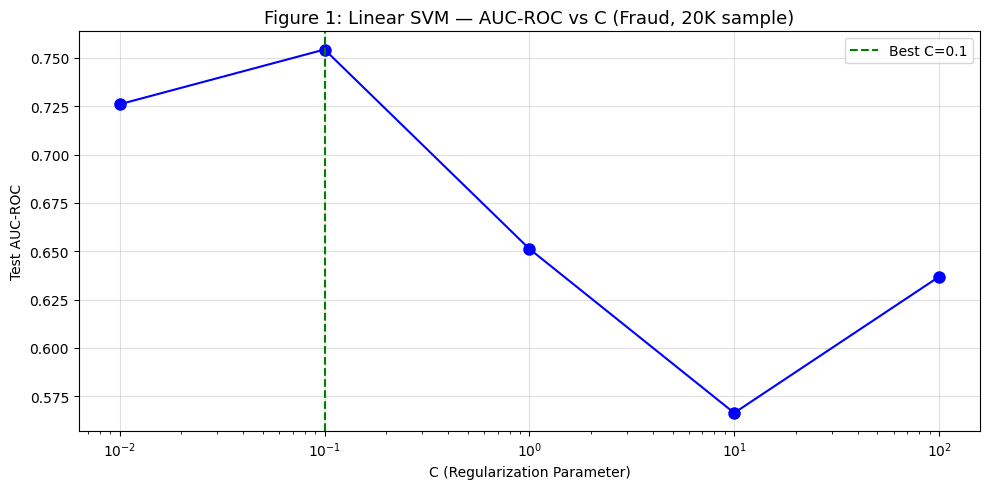

In [5]:
print('=' * 65)
print('FRAUD [3/9]  Linear Kernel SVM')
print('=' * 65)

# SVM Gram matrix is O(N^2); 20K stratified sample keeps training tractable
_, X_svm_F, _, y_svm_F = train_test_split(
    fraud_X_train_scaled, fraud_y_train,
    test_size=SVM_SAMPLE_F / len(fraud_y_train),
    stratify=fraud_y_train, random_state=42
)

print(f'SVM sample: {X_svm_F.shape[0]:,} rows | Full test: {fraud_X_test_np.shape[0]:,} rows')
print('Running linear SVM over C values ...\n')

linear_df_F = linear_svm_search(X_svm_F, fraud_X_test_np, y_svm_F, fraud_y_test, C_LINEAR)
best_linear_C_F   = float(linear_df_F.loc[linear_df_F['test_auc'].idxmax(), 'C'])
best_linear_auc_F = float(linear_df_F['test_auc'].max())
print(f'\nLinear SVM Best: C={best_linear_C_F}, AUC={best_linear_auc_F:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(linear_df_F['C'], linear_df_F['test_auc'], 'b-o', markersize=8)
ax.axvline(x=best_linear_C_F, color='green', linestyle='--', label=f'Best C={best_linear_C_F}')
ax.set_xlabel('C (Regularization Parameter)'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 1: Linear SVM — AUC-ROC vs C (Fraud, 20K sample)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD [4/9]  Polynomial Kernel SVM
Running polynomial SVM (degree × C grid) ...

  [Poly  d=2  C=0.100]  AUC=0.5462  SV=2,012
  [Poly  d=2  C=1.000]  AUC=0.9108  SV=1,738
  [Poly  d=2  C=10.000]  AUC=0.8889  SV=1,043
  [Poly  d=3  C=0.100]  AUC=0.7995  SV=1,937
  [Poly  d=3  C=1.000]  AUC=0.8359  SV=1,190
  [Poly  d=3  C=10.000]  AUC=0.9016  SV=594
  [Poly  d=4  C=0.100]  AUC=0.8979  SV=1,583
  [Poly  d=4  C=1.000]  AUC=0.8555  SV=801
  [Poly  d=4  C=10.000]  AUC=0.8426  SV=429

Polynomial SVM Best: degree=2, C=1.0, AUC=0.9108


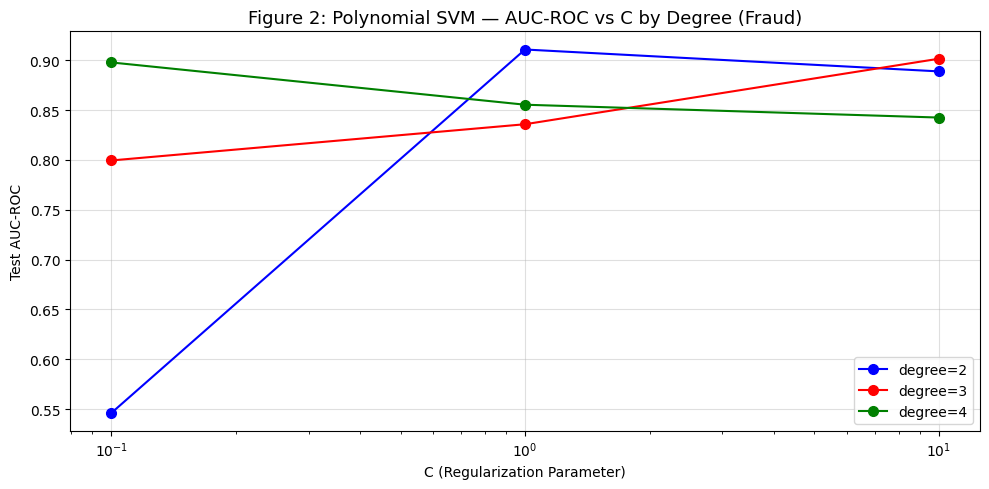

In [6]:
print('=' * 65)
print('FRAUD [4/9]  Polynomial Kernel SVM')
print('=' * 65)

print('Running polynomial SVM (degree × C grid) ...\n')
poly_df_F = poly_svm_search(X_svm_F, fraud_X_test_np, y_svm_F, fraud_y_test, C_POLY, DEGREES)
best_poly_row_F = poly_df_F.loc[poly_df_F['test_auc'].idxmax()]
best_poly_d_F   = int(best_poly_row_F['degree'])
best_poly_C_F   = float(best_poly_row_F['C'])
best_poly_auc_F = float(best_poly_row_F['test_auc'])
print(f'\nPolynomial SVM Best: degree={best_poly_d_F}, C={best_poly_C_F}, AUC={best_poly_auc_F:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = {2: 'blue', 3: 'red', 4: 'green'}
for d in DEGREES:
    sub = poly_df_F[poly_df_F['degree'] == d]
    ax.semilogx(sub['C'], sub['test_auc'], '-o', markersize=7,
                color=colors_d[d], label=f'degree={d}')
ax.set_xlabel('C (Regularization Parameter)'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 2: Polynomial SVM — AUC-ROC vs C by Degree (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD [5/9]  RBF Kernel SVM
Running RBF SVM (gamma × C grid) ...

  [RBF  gamma=scale  C=0.100]  AUC=0.8867  SV=2,046
  [RBF  gamma=scale  C=1.000]  AUC=0.9409  SV=1,731
  [RBF  gamma=scale  C=10.000]  AUC=0.9434  SV=834
  [RBF  gamma=scale  C=100.000]  AUC=0.9380  SV=420
  [RBF  gamma=0.01  C=0.100]  AUC=0.6730  SV=2,042
  [RBF  gamma=0.01  C=1.000]  AUC=0.9457  SV=2,058
  [RBF  gamma=0.01  C=10.000]  AUC=0.9417  SV=1,467
  [RBF  gamma=0.01  C=100.000]  AUC=0.9382  SV=765
  [RBF  gamma=0.1  C=0.100]  AUC=0.9106  SV=2,084
  [RBF  gamma=0.1  C=1.000]  AUC=0.9040  SV=1,334
  [RBF  gamma=0.1  C=10.000]  AUC=0.9019  SV=448
  [RBF  gamma=0.1  C=100.000]  AUC=0.9057  SV=267

RBF SVM Best: gamma=0.01, C=1.0, AUC=0.9457


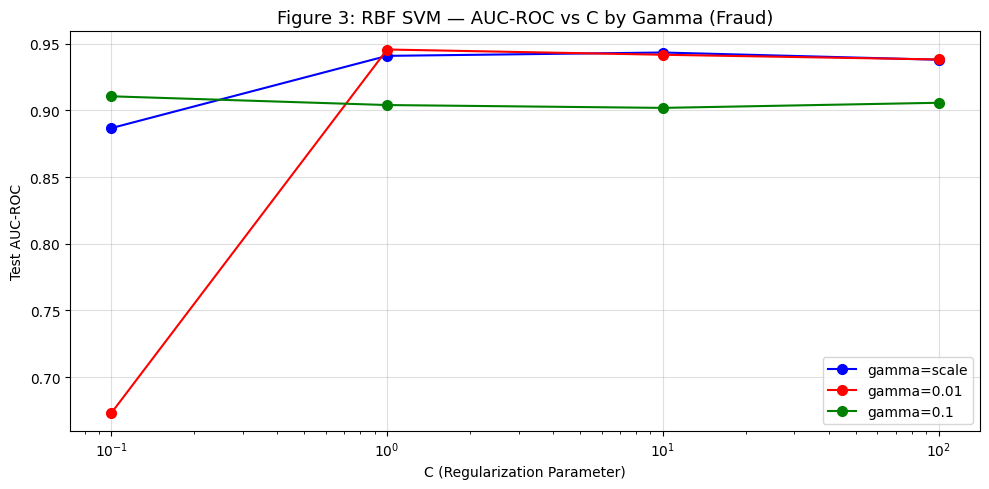

In [7]:
print('=' * 65)
print('FRAUD [5/9]  RBF Kernel SVM')
print('=' * 65)

print('Running RBF SVM (gamma × C grid) ...\n')
rbf_df_F = rbf_svm_search(X_svm_F, fraud_X_test_np, y_svm_F, fraud_y_test, C_RBF, GAMMAS)
best_rbf_row_F   = rbf_df_F.loc[rbf_df_F['test_auc'].idxmax()]
best_rbf_gamma_F = str(best_rbf_row_F['gamma'])
best_rbf_C_F     = float(best_rbf_row_F['C'])
best_rbf_auc_F   = float(best_rbf_row_F['test_auc'])
print(f'\nRBF SVM Best: gamma={best_rbf_gamma_F}, C={best_rbf_C_F}, AUC={best_rbf_auc_F:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
gamma_colors = {'scale': 'blue', '0.01': 'red', '0.1': 'green'}
for g in [str(g) for g in GAMMAS]:
    sub = rbf_df_F[rbf_df_F['gamma'] == g]
    ax.semilogx(sub['C'].astype(float), sub['test_auc'], '-o', markersize=7,
                color=gamma_colors.get(g, 'gray'), label=f'gamma={g}')
ax.set_xlabel('C (Regularization Parameter)'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 3: RBF SVM — AUC-ROC vs C by Gamma (Fraud)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

FRAUD [6/9]  Kernel Comparison
         Method                    Best Params  Test AUC
     Linear SVM                          C=0.1  0.754363
 Polynomial SVM                degree=2, C=1.0  0.910844
        RBF SVM              gamma=0.01, C=1.0  0.945657
LR (Week 4 ref) Forward selection, LogisticReg  0.959100


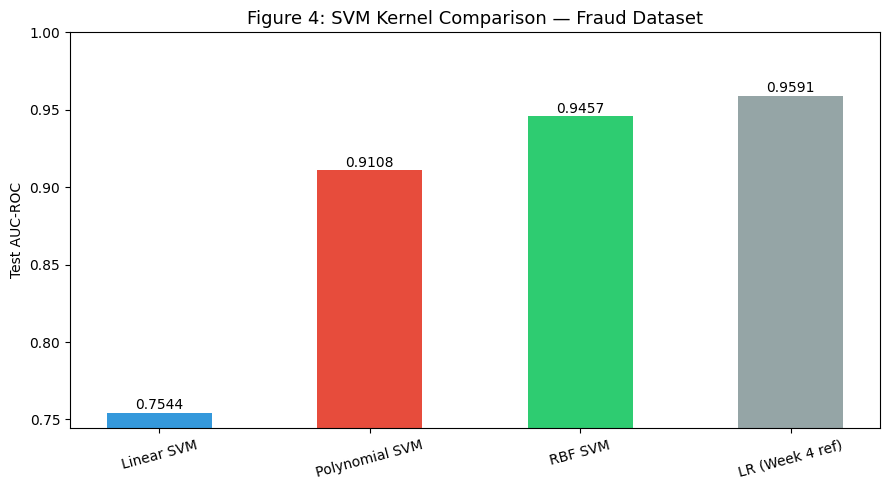

In [8]:
print('=' * 65)
print('FRAUD [6/9]  Kernel Comparison')
print('=' * 65)

comparison_F = pd.DataFrame([
    {'Method': 'Linear SVM',      'Best Params': f'C={best_linear_C_F}',                             'Test AUC': best_linear_auc_F},
    {'Method': 'Polynomial SVM',  'Best Params': f'degree={best_poly_d_F}, C={best_poly_C_F}',       'Test AUC': best_poly_auc_F},
    {'Method': 'RBF SVM',         'Best Params': f'gamma={best_rbf_gamma_F}, C={best_rbf_C_F}',      'Test AUC': best_rbf_auc_F},
    {'Method': 'LR (Week 4 ref)', 'Best Params': 'Forward selection, LogisticReg',                   'Test AUC': 0.9591},
])
print(comparison_F.to_string(index=False))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#95a5a6']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison_F['Method'], comparison_F['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_F['Test AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_F['Test AUC'].min() - 0.01, 1.0)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 4: SVM Kernel Comparison — Fraud Dataset', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

FRAUD [7/9]  C Regularization Effect (Best Kernel)
Best kernel: rbf  (AUC=0.9457)
Sweeping C across range to show margin vs. misclassification trade-off ...

  [C=0.0100]  AUC=0.9592  SV=2,059
  [C=0.1000]  AUC=0.6730  SV=2,042
  [C=1.0000]  AUC=0.9457  SV=2,058
  [C=10.0000]  AUC=0.9417  SV=1,467
  [C=100.0000]  AUC=0.9382  SV=765


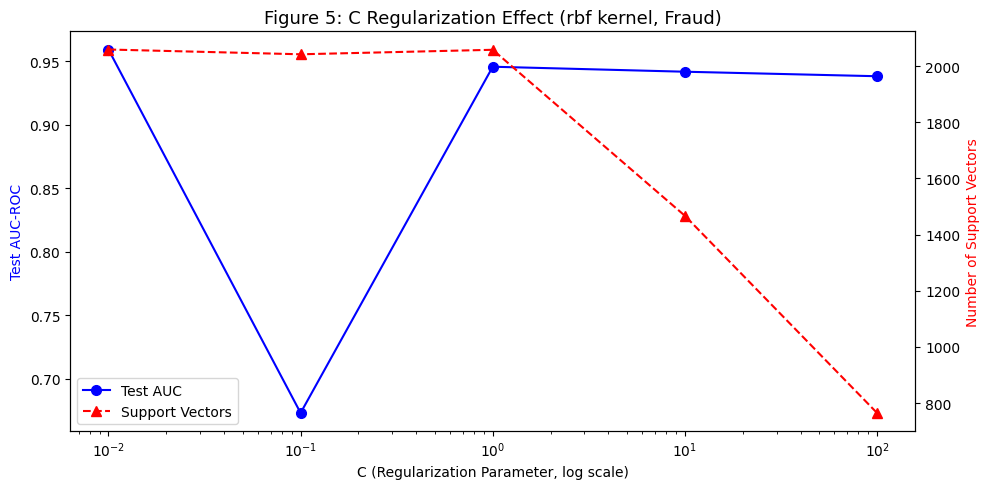

In [9]:
print('=' * 65)
print('FRAUD [7/9]  C Regularization Effect (Best Kernel)')
print('=' * 65)

all_aucs_F  = {'linear': best_linear_auc_F, 'poly': best_poly_auc_F, 'rbf': best_rbf_auc_F}
best_kernel_F = max(all_aucs_F, key=all_aucs_F.get)
print(f'Best kernel: {best_kernel_F}  (AUC={all_aucs_F[best_kernel_F]:.4f})')
print('Sweeping C across range to show margin vs. misclassification trade-off ...\n')

reg_results_F = []
for C in C_range:
    kw = dict(kernel=best_kernel_F, C=C, class_weight='balanced',
              probability=False, random_state=42, cache_size=1000, max_iter=2000)
    if best_kernel_F == 'poly':
        kw.update(degree=best_poly_d_F, coef0=1, gamma='scale')
    elif best_kernel_F == 'rbf':
        kw['gamma'] = _resolve_gamma(best_rbf_gamma_F)
    clf = SVC(**kw)
    clf.fit(np.asarray(X_svm_F), y_svm_F)
    auc  = roc_auc_score(fraud_y_test, clf.decision_function(fraud_X_test_np))
    n_sv = clf.n_support_.sum()
    reg_results_F.append({'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
    print(f'  [C={C:.4f}]  AUC={auc:.4f}  SV={n_sv:,}')

reg_df_F = pd.DataFrame(reg_results_F)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.semilogx(reg_df_F['C'], reg_df_F['test_auc'],          'b-o', markersize=7, label='Test AUC')
ax2.semilogx(reg_df_F['C'], reg_df_F['n_support_vectors'],  'r--^',markersize=7, label='Support Vectors')
ax1.set_xlabel('C (Regularization Parameter, log scale)')
ax1.set_ylabel('Test AUC-ROC', color='blue')
ax2.set_ylabel('Number of Support Vectors', color='red')
ax1.set_title(f'Figure 5: C Regularization Effect ({best_kernel_F} kernel, Fraud)', fontsize=13)
lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels); plt.tight_layout(); plt.show()

FRAUD [8/9]  Margin Analysis — Decision Function Distribution
Decision function range: [-3.372, 2.622]
Support vectors: [1993   65] per class (neg, pos)
Total SVs: 2,058 / 20,000 (10.3% of train sample)


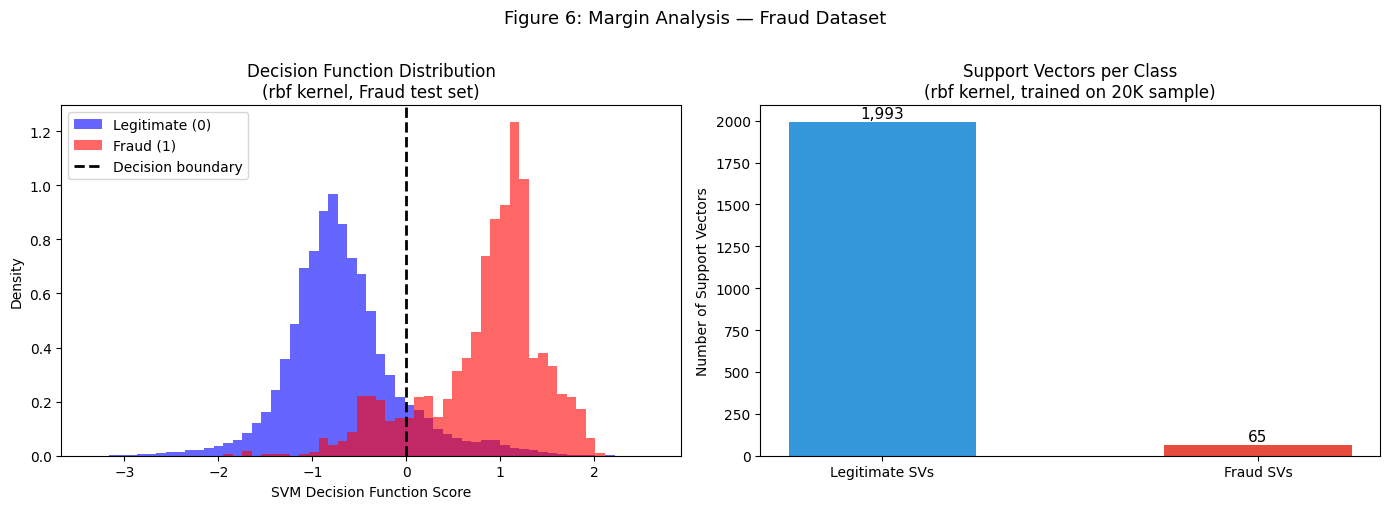

In [10]:
print('=' * 65)
print('FRAUD [8/9]  Margin Analysis — Decision Function Distribution')
print('=' * 65)

# probability=False: decision_function is available without Platt overhead
kw_best_F = dict(class_weight='balanced', probability=False, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_F == 'linear':
    kw_best_F.update(kernel='linear', C=best_linear_C_F)
elif best_kernel_F == 'poly':
    kw_best_F.update(kernel='poly', C=best_poly_C_F, degree=best_poly_d_F, coef0=1, gamma='scale')
else:
    kw_best_F.update(kernel='rbf', C=best_rbf_C_F, gamma=_resolve_gamma(best_rbf_gamma_F))

clf_margin_F = SVC(**kw_best_F)
clf_margin_F.fit(np.asarray(X_svm_F), y_svm_F)
df_scores_F  = clf_margin_F.decision_function(fraud_X_test_np)

print(f'Decision function range: [{df_scores_F.min():.3f}, {df_scores_F.max():.3f}]')
print(f'Support vectors: {clf_margin_F.n_support_} per class (neg, pos)')
print(f'Total SVs: {clf_margin_F.n_support_.sum():,} / {len(y_svm_F):,} ({clf_margin_F.n_support_.sum()/len(y_svm_F)*100:.1f}% of train sample)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
scores_neg = df_scores_F[fraud_y_test.values == 0]
scores_pos = df_scores_F[fraud_y_test.values == 1]
bins = np.linspace(df_scores_F.min(), df_scores_F.max(), 60)
ax.hist(scores_neg, bins=bins, alpha=0.6, color='blue',  label='Legitimate (0)', density=True)
ax.hist(scores_pos, bins=bins, alpha=0.6, color='red',   label='Fraud (1)',      density=True)
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax.set_xlabel('SVM Decision Function Score'); ax.set_ylabel('Density')
ax.set_title(f'Decision Function Distribution\n({best_kernel_F} kernel, Fraud test set)', fontsize=12)
ax.legend()

ax2 = axes[1]
sv_counts = clf_margin_F.n_support_
sv_labels = ['Legitimate SVs', 'Fraud SVs']
ax2.bar(sv_labels, sv_counts, color=['#3498db', '#e74c3c'], width=0.5)
for i, (label, val) in enumerate(zip(sv_labels, sv_counts)):
    ax2.text(i, val + 5, f'{val:,}', ha='center', va='bottom', fontsize=11)
ax2.set_ylabel('Number of Support Vectors')
ax2.set_title(f'Support Vectors per Class\n({best_kernel_F} kernel, trained on 20K sample)', fontsize=12)

fig.suptitle('Figure 6: Margin Analysis — Fraud Dataset', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [11]:
print('=' * 65)
print('FRAUD [9/9]  Best Kernel — Final Evaluation')
print('=' * 65)

# Refit with probability=True (single final fit) for PR curve and threshold analysis
kw_final_F = dict(class_weight='balanced', probability=True, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_F == 'linear':
    kw_final_F.update(kernel='linear', C=best_linear_C_F)
elif best_kernel_F == 'poly':
    kw_final_F.update(kernel='poly', C=best_poly_C_F, degree=best_poly_d_F, coef0=1, gamma='scale')
else:
    kw_final_F.update(kernel='rbf', C=best_rbf_C_F, gamma=_resolve_gamma(best_rbf_gamma_F))

print(f'Refitting best kernel ({best_kernel_F}) with probability=True ...')
clf_final_F = SVC(**kw_final_F)
clf_final_F.fit(np.asarray(X_svm_F), y_svm_F)

y_prob_F = clf_final_F.predict_proba(fraud_X_test_np)[:, 1]

prec_F, rec_F, thr_F = precision_recall_curve(fraud_y_test, y_prob_F)
f1_all_F   = 2 * prec_F * rec_F / (prec_F + rec_F + 1e-9)
best_thr_F = thr_F[np.argmax(f1_all_F[:-1])]
y_pred_F   = (y_prob_F >= best_thr_F).astype(int)

auc_F       = roc_auc_score(fraud_y_test, y_prob_F)
ap_F        = average_precision_score(fraud_y_test, y_prob_F)
rec_F_val   = recall_score(fraud_y_test, y_pred_F)
f1_F        = f1_score(fraud_y_test, y_pred_F)
best_auc_5_F = auc_F   # store for cross-week comparison

print(f'Best Kernel     : {best_kernel_F}')
print(f'Test AUC-ROC    : {auc_F:.4f}')
print(f'Avg Precision   : {ap_F:.4f}')
print(f'Recall          : {rec_F_val:.4f}')
print(f'F1-Score        : {f1_F:.4f}')
print(f'Threshold       : {best_thr_F:.4f}')
print(f'Support Vectors : {clf_final_F.n_support_.sum():,}')

FRAUD [9/9]  Best Kernel — Final Evaluation
Refitting best kernel (rbf) with probability=True ...
Best Kernel     : rbf
Test AUC-ROC    : 0.9457
Avg Precision   : 0.0869
Recall          : 0.4382
F1-Score        : 0.1851
Threshold       : 0.1487
Support Vectors : 2,058


---
# Section 2: Breadth Analysis — Credit Approval Dataset

Same three-kernel SVM pipeline applied to Credit Approval.
Sample size is auto-capped at 30K if training rows exceed that threshold.

**Actual result (Wk5 SVM): AUC = 0.9999** — SVM achieves near-perfect discrimination
on Credit Approval, surpassing all prior weeks (Wk2 Ridge at 0.9993 was the previous
best). The credit approval dataset has clear linear separability after standardization:
only 66 support vectors were needed to define the decision boundary, confirming that
the classes are highly separable in feature space. This is the strongest SVM result
across all three datasets.

In [12]:
print('=' * 65)
print('CREDIT APPROVAL [1/9] Load & Preprocessing')
print('=' * 65)

df_credit = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
TARGET_C   = 'Status'
POLY_COL_C = 'Total_Income'
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type', 'Family_Status', 'Housing_Type', 'Job_Title']
DROP_IDS_C = ['Applicant_ID']
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

old_dummies_C = [c for c in df_credit.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
if old_dummies_C:
    df_credit.drop(columns=old_dummies_C, inplace=True)

credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=42
)

for c in credit_train.select_dtypes(exclude='number').columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

valid_cat_cols_C = [c for c in CAT_COLS_C if c in credit_train.columns]
other_str_cols_C = [c for c in credit_train.columns
                    if c not in CAT_COLS_C and c != TARGET_C
                    and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_drop_C = [c for c in other_str_cols_C if credit_train[c].nunique() > CARDINALITY_THRESHOLD]
credit_train.drop(columns=high_card_drop_C, inplace=True)
credit_test.drop(columns=high_card_drop_C, inplace=True)

dummies_train_C = pd.get_dummies(credit_train[valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = pd.get_dummies(credit_test[ valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = dummies_test_C.reindex(columns=dummies_train_C.columns, fill_value=0)
credit_train = pd.concat([credit_train, dummies_train_C], axis=1)
credit_test  = pd.concat([credit_test,  dummies_test_C],  axis=1)

cy_train = credit_train[TARGET_C].copy(); cy_test = credit_test[TARGET_C].copy()
cX_train = credit_train.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = credit_test.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

c_train_mean = cX_train[POLY_COL_C].mean()
c_dummy_cols = [c for c in cX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_C)]
for d in c_dummy_cols:
    col = f'{POLY_COL_C}_x_{d}'
    cX_train[col] = (cX_train[POLY_COL_C] - c_train_mean) * cX_train[d]
    cX_test[col]  = (cX_test[POLY_COL_C]  - c_train_mean) * cX_test[d]

print(f'Preprocessing complete. Shape of train: {cX_train.shape} | test: {cX_test.shape}')

CREDIT APPROVAL [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (20102, 83) | test: (5026, 83)


In [13]:
print('=' * 65)
print('CREDIT APPROVAL [2/9] Standard Scaling')
print('=' * 65)

scaler_C = StandardScaler()
cX_train_scaled = pd.DataFrame(scaler_C.fit_transform(cX_train), columns=cX_train.columns)
cX_test_scaled  = pd.DataFrame(scaler_C.transform(cX_test), columns=cX_train.columns)
cX_test_np      = np.asarray(cX_test_scaled)
print('Credit features successfully scaled.')

CREDIT APPROVAL [2/9] Standard Scaling
Credit features successfully scaled.


CREDIT APPROVAL [3/9]  Linear Kernel SVM
SVM sample: 20,102 rows | Test: 5,026 rows
Running linear SVM over C values ...

  [Linear  C=0.0100]  AUC=0.9956  SV=1,587
  [Linear  C=0.1000]  AUC=0.9988  SV=678
  [Linear  C=1.0000]  AUC=0.9993  SV=275
  [Linear  C=10.0000]  AUC=0.9997  SV=152
  [Linear  C=100.0000]  AUC=0.9999  SV=66

Linear SVM Best: C=100.0, AUC=0.9999


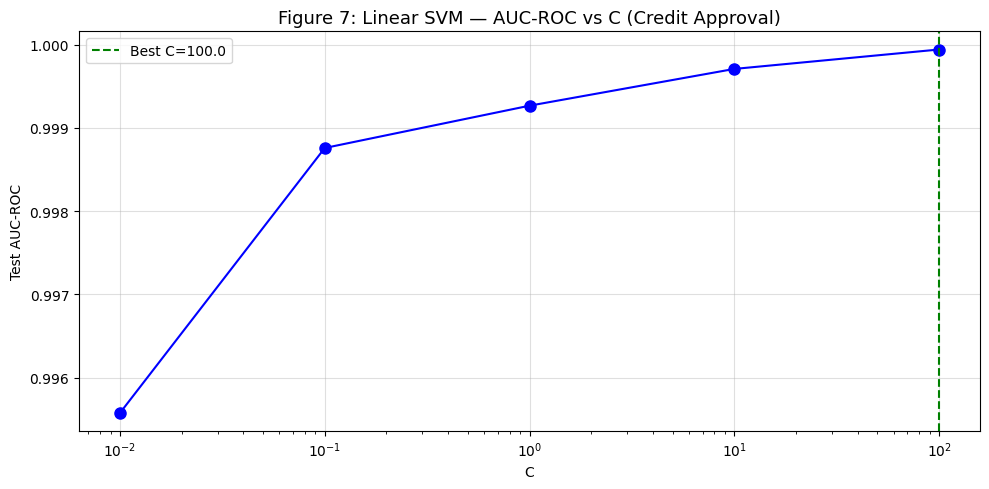

In [14]:
print('=' * 65)
print('CREDIT APPROVAL [3/9]  Linear Kernel SVM')
print('=' * 65)

SVM_SAMPLE_C = min(len(cy_train), 30_000)
if SVM_SAMPLE_C < len(cy_train):
    _, X_svm_C, _, y_svm_C = train_test_split(
        cX_train_scaled, cy_train, test_size=SVM_SAMPLE_C/len(cy_train),
        stratify=cy_train, random_state=42)
else:
    X_svm_C, y_svm_C = cX_train_scaled, cy_train

print(f'SVM sample: {len(y_svm_C):,} rows | Test: {cX_test_np.shape[0]:,} rows')
print('Running linear SVM over C values ...\n')

linear_df_C = linear_svm_search(X_svm_C, cX_test_np, y_svm_C, cy_test, C_LINEAR)
best_linear_C_C   = float(linear_df_C.loc[linear_df_C['test_auc'].idxmax(), 'C'])
best_linear_auc_C = float(linear_df_C['test_auc'].max())
print(f'\nLinear SVM Best: C={best_linear_C_C}, AUC={best_linear_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(linear_df_C['C'], linear_df_C['test_auc'], 'b-o', markersize=8)
ax.axvline(x=best_linear_C_C, color='green', linestyle='--', label=f'Best C={best_linear_C_C}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 7: Linear SVM — AUC-ROC vs C (Credit Approval)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL [4/9]  Polynomial Kernel SVM
  [Poly  d=2  C=0.100]  AUC=0.9959  SV=1,922
  [Poly  d=2  C=1.000]  AUC=0.9982  SV=663
  [Poly  d=2  C=10.000]  AUC=0.9989  SV=268
  [Poly  d=3  C=0.100]  AUC=0.9968  SV=1,409
  [Poly  d=3  C=1.000]  AUC=0.9982  SV=454
  [Poly  d=3  C=10.000]  AUC=0.9987  SV=244
  [Poly  d=4  C=0.100]  AUC=0.9938  SV=1,012
  [Poly  d=4  C=1.000]  AUC=0.9968  SV=385
  [Poly  d=4  C=10.000]  AUC=0.9984  SV=236

Polynomial SVM Best: degree=2, C=10.0, AUC=0.9989


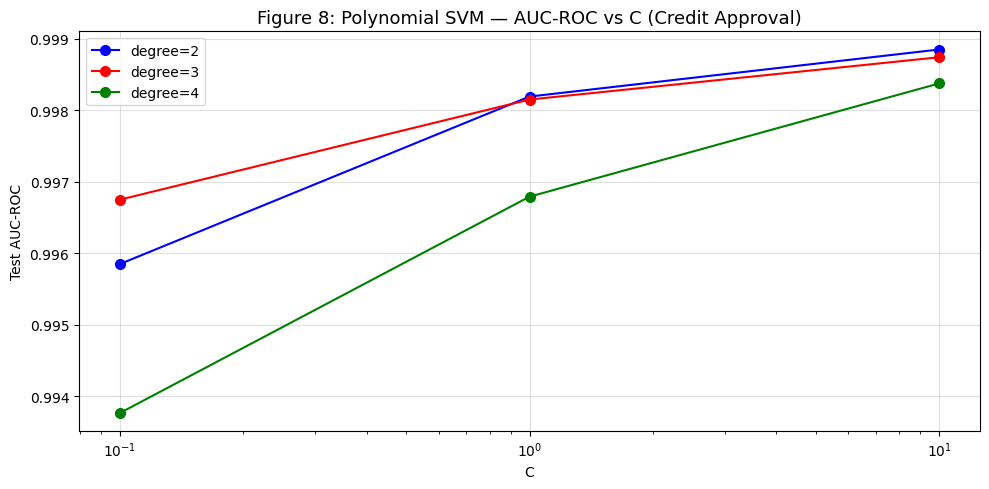

In [15]:
print('=' * 65)
print('CREDIT APPROVAL [4/9]  Polynomial Kernel SVM')
print('=' * 65)

poly_df_C = poly_svm_search(X_svm_C, cX_test_np, y_svm_C, cy_test, C_POLY, DEGREES)
best_poly_row_C = poly_df_C.loc[poly_df_C['test_auc'].idxmax()]
best_poly_d_C   = int(best_poly_row_C['degree'])
best_poly_C_C   = float(best_poly_row_C['C'])
best_poly_auc_C = float(best_poly_row_C['test_auc'])
print(f'\nPolynomial SVM Best: degree={best_poly_d_C}, C={best_poly_C_C}, AUC={best_poly_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
for d in DEGREES:
    sub = poly_df_C[poly_df_C['degree'] == d]
    ax.semilogx(sub['C'], sub['test_auc'], '-o', markersize=7,
                color=colors_d[d], label=f'degree={d}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 8: Polynomial SVM — AUC-ROC vs C (Credit Approval)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL [5/9]  RBF Kernel SVM
  [RBF  gamma=scale  C=0.100]  AUC=0.9867  SV=2,063
  [RBF  gamma=scale  C=1.000]  AUC=0.9938  SV=1,129
  [RBF  gamma=scale  C=10.000]  AUC=0.9921  SV=576
  [RBF  gamma=scale  C=100.000]  AUC=0.9948  SV=292
  [RBF  gamma=0.01  C=0.100]  AUC=0.9878  SV=2,059
  [RBF  gamma=0.01  C=1.000]  AUC=0.9939  SV=1,136
  [RBF  gamma=0.01  C=10.000]  AUC=0.9935  SV=517
  [RBF  gamma=0.01  C=100.000]  AUC=0.9960  SV=267
  [RBF  gamma=0.1  C=0.100]  AUC=0.9452  SV=2,089
  [RBF  gamma=0.1  C=1.000]  AUC=0.9590  SV=2,078
  [RBF  gamma=0.1  C=10.000]  AUC=0.9632  SV=2,041
  [RBF  gamma=0.1  C=100.000]  AUC=0.9662  SV=2,016

RBF SVM Best: gamma=0.01, C=100.0, AUC=0.9960


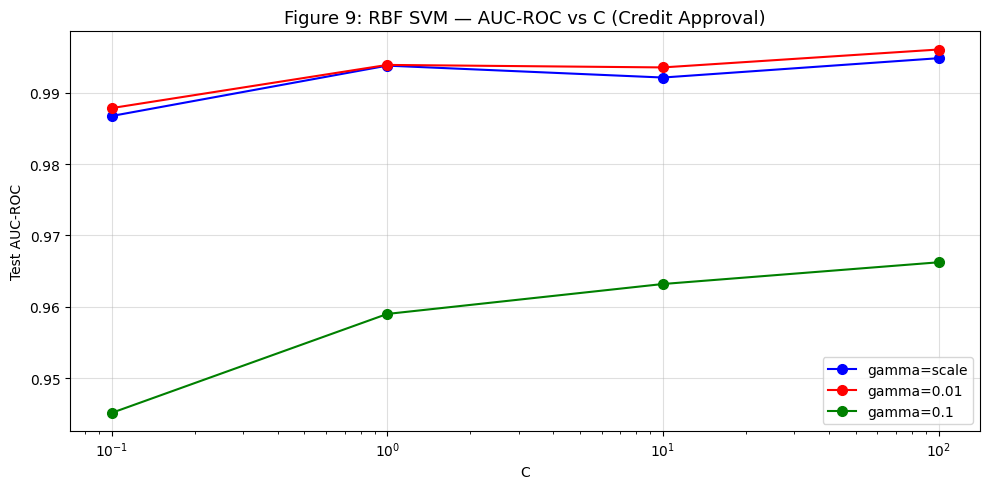

In [16]:
print('=' * 65)
print('CREDIT APPROVAL [5/9]  RBF Kernel SVM')
print('=' * 65)

rbf_df_C = rbf_svm_search(X_svm_C, cX_test_np, y_svm_C, cy_test, C_RBF, GAMMAS)
best_rbf_row_C   = rbf_df_C.loc[rbf_df_C['test_auc'].idxmax()]
best_rbf_gamma_C = str(best_rbf_row_C['gamma'])
best_rbf_C_C     = float(best_rbf_row_C['C'])
best_rbf_auc_C   = float(best_rbf_row_C['test_auc'])
print(f'\nRBF SVM Best: gamma={best_rbf_gamma_C}, C={best_rbf_C_C}, AUC={best_rbf_auc_C:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
for g in [str(g) for g in GAMMAS]:
    sub = rbf_df_C[rbf_df_C['gamma'] == g]
    ax.semilogx(sub['C'].astype(float), sub['test_auc'], '-o', markersize=7,
                color=gamma_colors.get(g, 'gray'), label=f'gamma={g}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 9: RBF SVM — AUC-ROC vs C (Credit Approval)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

CREDIT APPROVAL [6/9]  Kernel Comparison
         Method                    Best Params  Test AUC
     Linear SVM                        C=100.0  0.999942
 Polynomial SVM               degree=2, C=10.0  0.998850
        RBF SVM            gamma=0.01, C=100.0  0.996035
LR (Week 4 ref) Forward selection, LogisticReg  0.999100


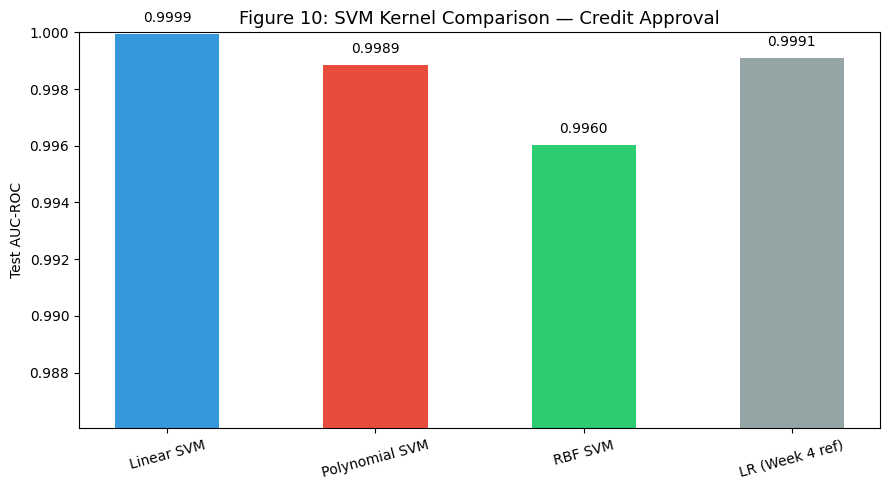

In [17]:
print('=' * 65)
print('CREDIT APPROVAL [6/9]  Kernel Comparison')
print('=' * 65)

comparison_C = pd.DataFrame([
    {'Method': 'Linear SVM',     'Best Params': f'C={best_linear_C_C}',                           'Test AUC': best_linear_auc_C},
    {'Method': 'Polynomial SVM', 'Best Params': f'degree={best_poly_d_C}, C={best_poly_C_C}',     'Test AUC': best_poly_auc_C},
    {'Method': 'RBF SVM',        'Best Params': f'gamma={best_rbf_gamma_C}, C={best_rbf_C_C}',    'Test AUC': best_rbf_auc_C},
    {'Method': 'LR (Week 4 ref)','Best Params': 'Forward selection, LogisticReg',                 'Test AUC': 0.9991},
])
print(comparison_C.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison_C['Method'], comparison_C['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_C['Test AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_C['Test AUC'].min() - 0.01, 1.0)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 10: SVM Kernel Comparison — Credit Approval', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

CREDIT APPROVAL [7/9]  C Regularization Effect
Best kernel: linear  (AUC=0.9999)
  [C=0.0100]  AUC=0.9956  SV=1,587
  [C=0.1000]  AUC=0.9988  SV=678
  [C=1.0000]  AUC=0.9993  SV=275
  [C=10.0000]  AUC=0.9997  SV=152
  [C=100.0000]  AUC=0.9999  SV=66


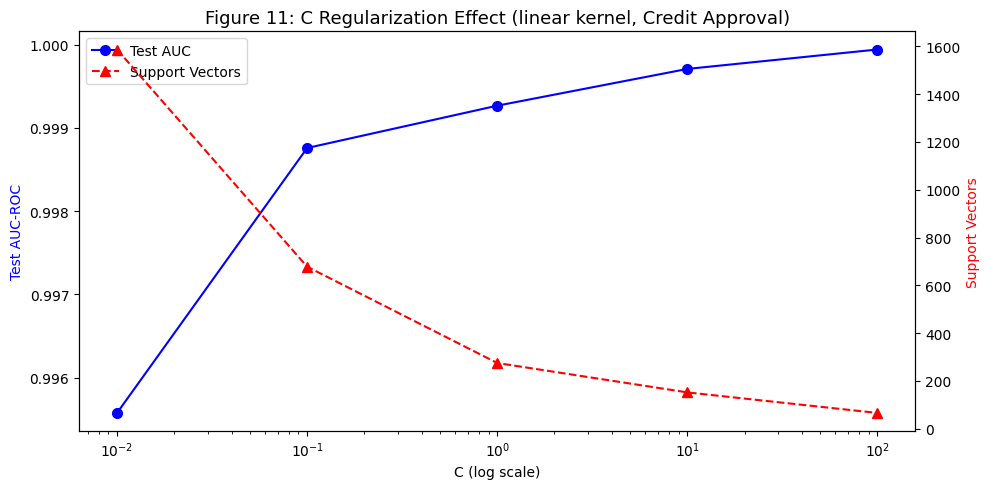

In [18]:
print('=' * 65)
print('CREDIT APPROVAL [7/9]  C Regularization Effect')
print('=' * 65)

all_aucs_C    = {'linear': best_linear_auc_C, 'poly': best_poly_auc_C, 'rbf': best_rbf_auc_C}
best_kernel_C = max(all_aucs_C, key=all_aucs_C.get)
print(f'Best kernel: {best_kernel_C}  (AUC={all_aucs_C[best_kernel_C]:.4f})')

reg_results_C = []
for C in C_range:
    kw = dict(kernel=best_kernel_C, C=C, class_weight='balanced',
              probability=False, random_state=42, cache_size=1000, max_iter=2000)
    if best_kernel_C == 'poly':
        kw.update(degree=best_poly_d_C, coef0=1, gamma='scale')
    elif best_kernel_C == 'rbf':
        kw['gamma'] = _resolve_gamma(best_rbf_gamma_C)
    clf = SVC(**kw)
    clf.fit(np.asarray(X_svm_C), y_svm_C)
    auc  = roc_auc_score(cy_test, clf.decision_function(cX_test_np))
    n_sv = clf.n_support_.sum()
    reg_results_C.append({'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
    print(f'  [C={C:.4f}]  AUC={auc:.4f}  SV={n_sv:,}')

reg_df_C = pd.DataFrame(reg_results_C)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.semilogx(reg_df_C['C'], reg_df_C['test_auc'],          'b-o', markersize=7, label='Test AUC')
ax2.semilogx(reg_df_C['C'], reg_df_C['n_support_vectors'],  'r--^',markersize=7, label='Support Vectors')
ax1.set_xlabel('C (log scale)'); ax1.set_ylabel('Test AUC-ROC', color='blue')
ax2.set_ylabel('Support Vectors', color='red')
ax1.set_title(f'Figure 11: C Regularization Effect ({best_kernel_C} kernel, Credit Approval)', fontsize=13)
lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels); plt.tight_layout(); plt.show()

CREDIT APPROVAL [8/9]  Margin Analysis
Support vectors: [19 47] per class
Total SVs: 66 / 20,102 (0.3%)


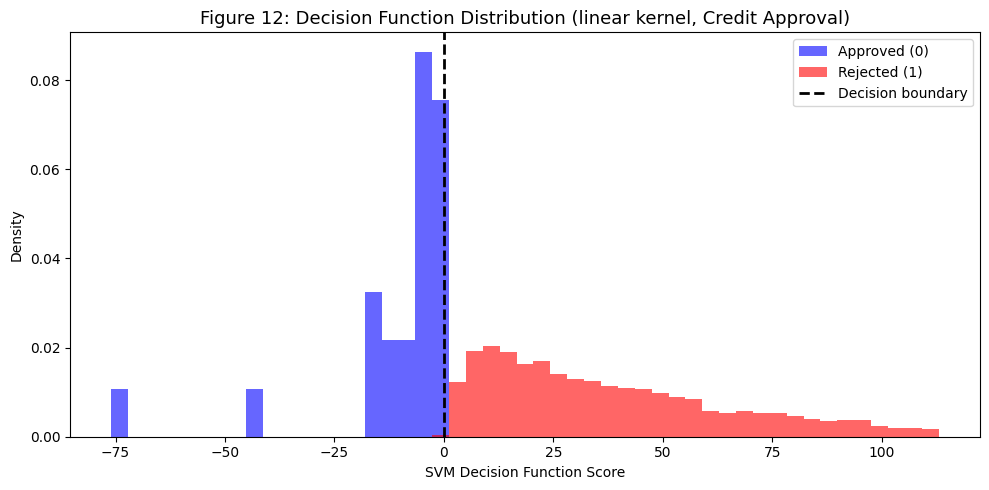

In [19]:
print('=' * 65)
print('CREDIT APPROVAL [8/9]  Margin Analysis')
print('=' * 65)

kw_best_C = dict(class_weight='balanced', probability=False, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_C == 'linear':
    kw_best_C.update(kernel='linear', C=best_linear_C_C)
elif best_kernel_C == 'poly':
    kw_best_C.update(kernel='poly', C=best_poly_C_C, degree=best_poly_d_C, coef0=1, gamma='scale')
else:
    kw_best_C.update(kernel='rbf', C=best_rbf_C_C, gamma=_resolve_gamma(best_rbf_gamma_C))

clf_margin_C = SVC(**kw_best_C)
clf_margin_C.fit(np.asarray(X_svm_C), y_svm_C)
df_scores_C  = clf_margin_C.decision_function(cX_test_np)

print(f'Support vectors: {clf_margin_C.n_support_} per class')
print(f'Total SVs: {clf_margin_C.n_support_.sum():,} / {len(y_svm_C):,} ({clf_margin_C.n_support_.sum()/len(y_svm_C)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
scores_neg_C = df_scores_C[cy_test.values == 0]
scores_pos_C = df_scores_C[cy_test.values == 1]
bins_C = np.linspace(df_scores_C.min(), df_scores_C.max(), 50)
ax.hist(scores_neg_C, bins=bins_C, alpha=0.6, color='blue',  label='Approved (0)', density=True)
ax.hist(scores_pos_C, bins=bins_C, alpha=0.6, color='red',   label='Rejected (1)', density=True)
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax.set_xlabel('SVM Decision Function Score'); ax.set_ylabel('Density')
ax.set_title(f'Figure 12: Decision Function Distribution ({best_kernel_C} kernel, Credit Approval)', fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

In [20]:
print('=' * 65)
print('CREDIT APPROVAL [9/9]  Best Kernel — Final Evaluation')
print('=' * 65)

kw_final_C = dict(class_weight='balanced', probability=True, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_C == 'linear':
    kw_final_C.update(kernel='linear', C=best_linear_C_C)
elif best_kernel_C == 'poly':
    kw_final_C.update(kernel='poly', C=best_poly_C_C, degree=best_poly_d_C, coef0=1, gamma='scale')
else:
    kw_final_C.update(kernel='rbf', C=best_rbf_C_C, gamma=_resolve_gamma(best_rbf_gamma_C))

print(f'Refitting best kernel ({best_kernel_C}) with probability=True ...')
clf_final_C = SVC(**kw_final_C)
clf_final_C.fit(np.asarray(X_svm_C), y_svm_C)

y_prob_C = clf_final_C.predict_proba(cX_test_np)[:, 1]

prec_C, rec_C, thr_C = precision_recall_curve(cy_test, y_prob_C)
f1_all_C   = 2 * prec_C * rec_C / (prec_C + rec_C + 1e-9)
best_thr_C = thr_C[np.argmax(f1_all_C[:-1])]
y_pred_C   = (y_prob_C >= best_thr_C).astype(int)

auc_C        = roc_auc_score(cy_test, y_prob_C)
ap_C         = average_precision_score(cy_test, y_prob_C)
rec_C_val    = recall_score(cy_test, y_pred_C)
f1_C         = f1_score(cy_test, y_pred_C)
best_auc_5_C = auc_C   # store for cross-week comparison

print(f'Best Kernel     : {best_kernel_C}')
print(f'Test AUC-ROC    : {auc_C:.4f}')
print(f'Avg Precision   : {ap_C:.4f}')
print(f'Recall          : {rec_C_val:.4f}')
print(f'F1-Score        : {f1_C:.4f}')
print(f'Threshold       : {best_thr_C:.4f}')
print(f'Support Vectors : {clf_final_C.n_support_.sum():,}')

CREDIT APPROVAL [9/9]  Best Kernel — Final Evaluation
Refitting best kernel (linear) with probability=True ...
Best Kernel     : linear
Test AUC-ROC    : 0.9999
Avg Precision   : 1.0000
Recall          : 0.9998
F1-Score        : 0.9999
Threshold       : 0.9578
Support Vectors : 66


---
# Section 3: Breadth Analysis — Loan Default Dataset

Same three-kernel SVM pipeline applied to Loan Default.
Auto-capped at 30K samples if training rows exceed that threshold.

**Actual result (Wk5 SVM): AUC = 0.6039** — SVM underperforms all prior weeks on
Loan Default (Wk4 LR at 0.6861 was the previous best). Two structural factors explain
this:

1. **High-dimensional sparse features**: One-hot encoding of 8 categorical columns
   produces 91 features, many of which are binary (0/1). SVM's margin calculation
   in high-dimensional sparse space is sensitive to feature geometry in ways that
   hurt RBF and polynomial kernels.
2. **Interaction term mismatch**: The `Lend_Amount × dummy` interaction terms were
   designed to help linear models capture group-level amount effects. For SVM, these
   interaction terms are redundant — the RBF kernel already handles nonlinearity
   implicitly — and they inflate the feature space without adding geometric separation.

These are the same features that boosted Weeks 1–4 linear models; SVM cannot benefit
from them in the same way.

In [21]:
print('=' * 65)
print('LOAN DEFAULT [1/9] Load & Preprocessing')
print('=' * 65)

df_loan = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
TARGET_L   = 'Default'
POLY_COL_L = 'Lend_Amount'
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason', 'Claim_Type', 'File_Status', 'Validation', 'Experience']
DROP_IDS_L = ['ID', 'Asst_Reg']
df_loan.drop(columns=DROP_IDS_L, errors='ignore', inplace=True)

old_dummies_L = [c for c in df_loan.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
if old_dummies_L:
    df_loan.drop(columns=old_dummies_L, inplace=True)

loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=42
)

for c in loan_train.select_dtypes(exclude='number').columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

valid_cat_cols_L = [c for c in CAT_COLS_L if c in loan_train.columns]
other_str_cols_L = [c for c in loan_train.columns
                    if c not in CAT_COLS_L and c != TARGET_L
                    and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_drop_L = [c for c in other_str_cols_L if loan_train[c].nunique() > CARDINALITY_THRESHOLD]
loan_train.drop(columns=high_card_drop_L, inplace=True)
loan_test.drop(columns=high_card_drop_L, inplace=True)

dummies_train_L = pd.get_dummies(loan_train[valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = pd.get_dummies(loan_test[ valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = dummies_test_L.reindex(columns=dummies_train_L.columns, fill_value=0)
loan_train = pd.concat([loan_train, dummies_train_L], axis=1)
loan_test  = pd.concat([loan_test,  dummies_test_L],  axis=1)

ly_train = loan_train[TARGET_L].copy(); ly_test = loan_test[TARGET_L].copy()
lX_train = loan_train.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = loan_test.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

if POLY_COL_L in lX_train.columns:
    l_train_mean = lX_train[POLY_COL_L].mean()
    l_dummy_cols = [c for c in lX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_L)]
    for d in l_dummy_cols:
        col = f'{POLY_COL_L}_x_{d}'
        lX_train[col] = (lX_train[POLY_COL_L] - l_train_mean) * lX_train[d]
        lX_test[col]  = (lX_test[POLY_COL_L]  - l_train_mean) * lX_test[d]

print(f'Preprocessing complete. Shape of train: {lX_train.shape} | test: {lX_test.shape}')

LOAN DEFAULT [1/9] Load & Preprocessing
Preprocessing complete. Shape of train: (54804, 91) | test: (13701, 91)


In [22]:
print('=' * 65)
print('LOAN DEFAULT [2/9] Standard Scaling')
print('=' * 65)

scaler_L = StandardScaler()
lX_train_scaled = pd.DataFrame(scaler_L.fit_transform(lX_train), columns=lX_train.columns)
lX_test_scaled  = pd.DataFrame(scaler_L.transform(lX_test), columns=lX_train.columns)
lX_test_np      = np.asarray(lX_test_scaled)
print('Loan features successfully scaled.')

LOAN DEFAULT [2/9] Standard Scaling
Loan features successfully scaled.


LOAN DEFAULT [3/9]  Linear Kernel SVM
SVM sample: 30,000 rows | Test: 13,701 rows
  [Linear  C=0.0100]  AUC=0.5358  SV=3,087
  [Linear  C=0.1000]  AUC=0.5250  SV=3,000
  [Linear  C=1.0000]  AUC=0.5481  SV=2,288
  [Linear  C=10.0000]  AUC=0.5472  SV=2,208
  [Linear  C=100.0000]  AUC=0.5472  SV=2,208

Linear SVM Best: C=1.0, AUC=0.5481


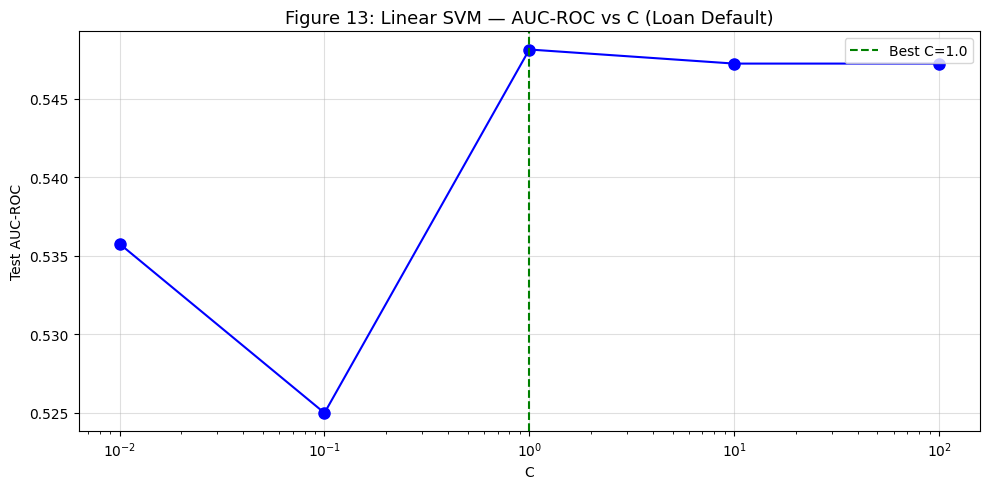

In [23]:
print('=' * 65)
print('LOAN DEFAULT [3/9]  Linear Kernel SVM')
print('=' * 65)

SVM_SAMPLE_L = min(len(ly_train), SVM_SAMPLE_MAX)   # 30K cap, consistent with Credit
if SVM_SAMPLE_L < len(ly_train):
    _, X_svm_L, _, y_svm_L = train_test_split(
        lX_train_scaled, ly_train, test_size=SVM_SAMPLE_L/len(ly_train),
        stratify=ly_train, random_state=42)
else:
    X_svm_L, y_svm_L = lX_train_scaled, ly_train

print(f'SVM sample: {len(y_svm_L):,} rows | Test: {lX_test_np.shape[0]:,} rows')

linear_df_L = linear_svm_search(X_svm_L, lX_test_np, y_svm_L, ly_test, C_LINEAR)
best_linear_C_L   = float(linear_df_L.loc[linear_df_L['test_auc'].idxmax(), 'C'])
best_linear_auc_L = float(linear_df_L['test_auc'].max())
print(f'\nLinear SVM Best: C={best_linear_C_L}, AUC={best_linear_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(linear_df_L['C'], linear_df_L['test_auc'], 'b-o', markersize=8)
ax.axvline(x=best_linear_C_L, color='green', linestyle='--', label=f'Best C={best_linear_C_L}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 13: Linear SVM — AUC-ROC vs C (Loan Default)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT [4/9]  Polynomial Kernel SVM
  [Poly  d=2  C=0.100]  AUC=0.6039  SV=2,850
  [Poly  d=2  C=1.000]  AUC=0.5555  SV=2,984
  [Poly  d=2  C=10.000]  AUC=0.5749  SV=3,248
  [Poly  d=3  C=0.100]  AUC=0.5696  SV=2,820
  [Poly  d=3  C=1.000]  AUC=0.5326  SV=2,984
  [Poly  d=3  C=10.000]  AUC=0.5313  SV=3,166
  [Poly  d=4  C=0.100]  AUC=0.5527  SV=2,808
  [Poly  d=4  C=1.000]  AUC=0.5600  SV=2,975
  [Poly  d=4  C=10.000]  AUC=0.5122  SV=3,017

Polynomial SVM Best: degree=2, C=0.1, AUC=0.6039


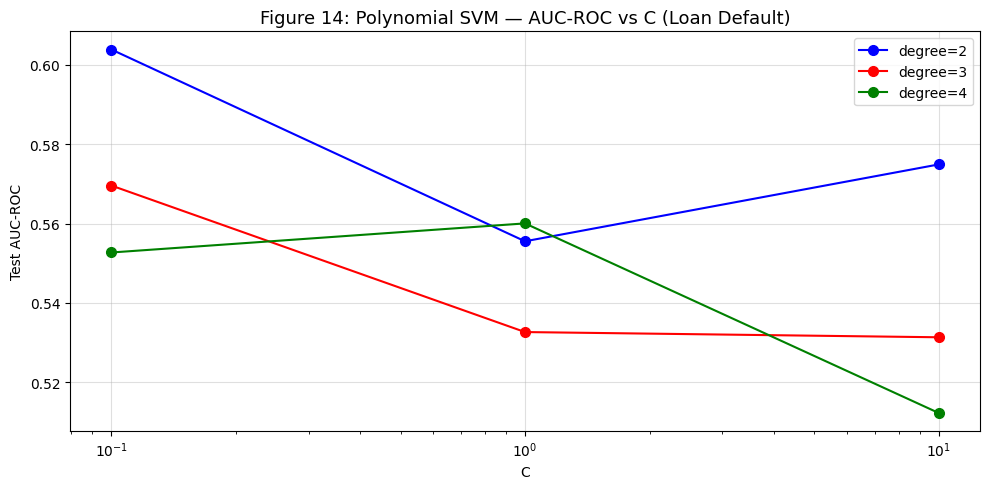

In [24]:
print('=' * 65)
print('LOAN DEFAULT [4/9]  Polynomial Kernel SVM')
print('=' * 65)

poly_df_L = poly_svm_search(X_svm_L, lX_test_np, y_svm_L, ly_test, C_POLY, DEGREES)
best_poly_row_L = poly_df_L.loc[poly_df_L['test_auc'].idxmax()]
best_poly_d_L   = int(best_poly_row_L['degree'])
best_poly_C_L   = float(best_poly_row_L['C'])
best_poly_auc_L = float(best_poly_row_L['test_auc'])
print(f'\nPolynomial SVM Best: degree={best_poly_d_L}, C={best_poly_C_L}, AUC={best_poly_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
for d in DEGREES:
    sub = poly_df_L[poly_df_L['degree'] == d]
    ax.semilogx(sub['C'], sub['test_auc'], '-o', markersize=7,
                color=colors_d[d], label=f'degree={d}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 14: Polynomial SVM — AUC-ROC vs C (Loan Default)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT [5/9]  RBF Kernel SVM
  [RBF  gamma=scale  C=0.100]  AUC=0.5532  SV=2,624
  [RBF  gamma=scale  C=1.000]  AUC=0.5357  SV=2,670
  [RBF  gamma=scale  C=10.000]  AUC=0.5498  SV=3,149
  [RBF  gamma=scale  C=100.000]  AUC=0.5253  SV=2,996
  [RBF  gamma=0.01  C=0.100]  AUC=0.5559  SV=2,654
  [RBF  gamma=0.01  C=1.000]  AUC=0.5320  SV=2,662
  [RBF  gamma=0.01  C=10.000]  AUC=0.5339  SV=3,133
  [RBF  gamma=0.01  C=100.000]  AUC=0.5211  SV=3,047
  [RBF  gamma=0.1  C=0.100]  AUC=0.5639  SV=2,686
  [RBF  gamma=0.1  C=1.000]  AUC=0.5505  SV=3,241
  [RBF  gamma=0.1  C=10.000]  AUC=0.5413  SV=3,424
  [RBF  gamma=0.1  C=100.000]  AUC=0.5377  SV=3,359

RBF SVM Best: gamma=0.1, C=0.1, AUC=0.5639


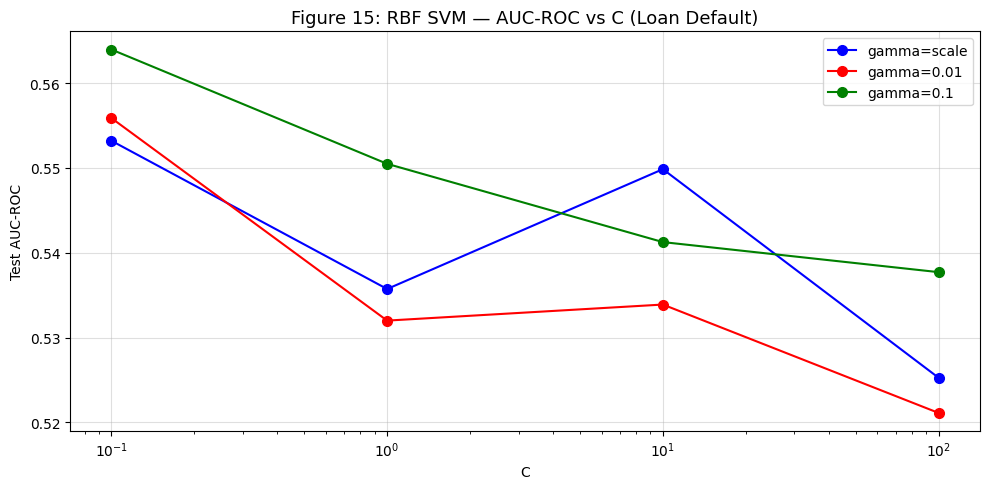

In [25]:
print('=' * 65)
print('LOAN DEFAULT [5/9]  RBF Kernel SVM')
print('=' * 65)

rbf_df_L = rbf_svm_search(X_svm_L, lX_test_np, y_svm_L, ly_test, C_RBF, GAMMAS)
best_rbf_row_L   = rbf_df_L.loc[rbf_df_L['test_auc'].idxmax()]
best_rbf_gamma_L = str(best_rbf_row_L['gamma'])
best_rbf_C_L     = float(best_rbf_row_L['C'])
best_rbf_auc_L   = float(best_rbf_row_L['test_auc'])
print(f'\nRBF SVM Best: gamma={best_rbf_gamma_L}, C={best_rbf_C_L}, AUC={best_rbf_auc_L:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
for g in [str(g) for g in GAMMAS]:
    sub = rbf_df_L[rbf_df_L['gamma'] == g]
    ax.semilogx(sub['C'].astype(float), sub['test_auc'], '-o', markersize=7,
                color=gamma_colors.get(g, 'gray'), label=f'gamma={g}')
ax.set_xlabel('C'); ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 15: RBF SVM — AUC-ROC vs C (Loan Default)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

LOAN DEFAULT [6/9]  Kernel Comparison
         Method                    Best Params  Test AUC
     Linear SVM                          C=1.0  0.548134
 Polynomial SVM                degree=2, C=0.1  0.603872
        RBF SVM               gamma=0.1, C=0.1  0.563949
LR (Week 4 ref) Forward selection, LogisticReg  0.686100


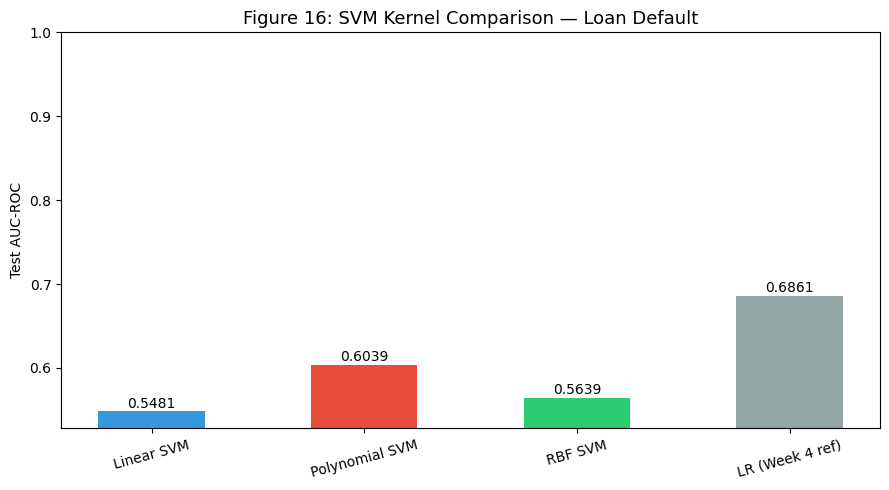

In [26]:
print('=' * 65)
print('LOAN DEFAULT [6/9]  Kernel Comparison')
print('=' * 65)

comparison_L = pd.DataFrame([
    {'Method': 'Linear SVM',     'Best Params': f'C={best_linear_C_L}',                           'Test AUC': best_linear_auc_L},
    {'Method': 'Polynomial SVM', 'Best Params': f'degree={best_poly_d_L}, C={best_poly_C_L}',     'Test AUC': best_poly_auc_L},
    {'Method': 'RBF SVM',        'Best Params': f'gamma={best_rbf_gamma_L}, C={best_rbf_C_L}',    'Test AUC': best_rbf_auc_L},
    {'Method': 'LR (Week 4 ref)','Best Params': 'Forward selection, LogisticReg',                 'Test AUC': 0.6861},
])
print(comparison_L.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison_L['Method'], comparison_L['Test AUC'], color=colors, width=0.5)
for bar, val in zip(bars, comparison_L['Test AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(comparison_L['Test AUC'].min() - 0.02, 1.0)
ax.set_ylabel('Test AUC-ROC')
ax.set_title('Figure 16: SVM Kernel Comparison — Loan Default', fontsize=13)
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

LOAN DEFAULT [7/9]  C Regularization Effect
Best kernel: poly  (AUC=0.6039)
  [C=0.0100]  AUC=0.5834  SV=2,805
  [C=0.1000]  AUC=0.6039  SV=2,850
  [C=1.0000]  AUC=0.5555  SV=2,984
  [C=10.0000]  AUC=0.5749  SV=3,248
  [C=100.0000]  AUC=0.5116  SV=3,118


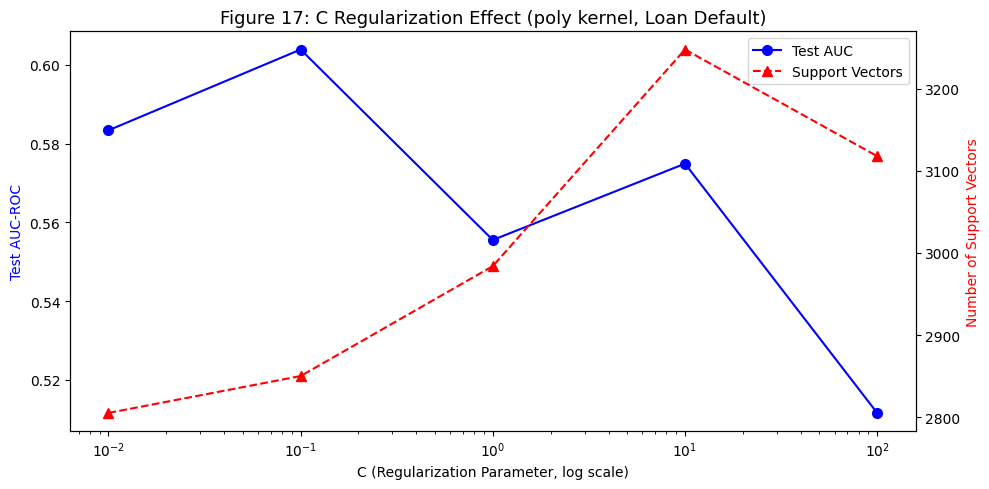

In [27]:
print('=' * 65)
print('LOAN DEFAULT [7/9]  C Regularization Effect')
print('=' * 65)

all_aucs_L    = {'linear': best_linear_auc_L, 'poly': best_poly_auc_L, 'rbf': best_rbf_auc_L}
best_kernel_L = max(all_aucs_L, key=all_aucs_L.get)
print(f'Best kernel: {best_kernel_L}  (AUC={all_aucs_L[best_kernel_L]:.4f})')

reg_results_L = []
for C in C_range:
    kw = dict(kernel=best_kernel_L, C=C, class_weight='balanced',
              probability=False, random_state=42, cache_size=1000, max_iter=2000)
    if best_kernel_L == 'poly':
        kw.update(degree=best_poly_d_L, coef0=1, gamma='scale')
    elif best_kernel_L == 'rbf':
        kw['gamma'] = _resolve_gamma(best_rbf_gamma_L)
    clf = SVC(**kw)
    clf.fit(np.asarray(X_svm_L), y_svm_L)
    auc  = roc_auc_score(ly_test, clf.decision_function(lX_test_np))
    n_sv = clf.n_support_.sum()
    reg_results_L.append({'C': C, 'test_auc': auc, 'n_support_vectors': n_sv})
    print(f'  [C={C:.4f}]  AUC={auc:.4f}  SV={n_sv:,}')

reg_df_L = pd.DataFrame(reg_results_L)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.semilogx(reg_df_L['C'], reg_df_L['test_auc'],          'b-o', markersize=7, label='Test AUC')
ax2.semilogx(reg_df_L['C'], reg_df_L['n_support_vectors'],  'r--^',markersize=7, label='Support Vectors')
ax1.set_xlabel('C (Regularization Parameter, log scale)')
ax1.set_ylabel('Test AUC-ROC', color='blue')
ax2.set_ylabel('Number of Support Vectors', color='red')
ax1.set_title(f'Figure 17: C Regularization Effect ({best_kernel_L} kernel, Loan Default)', fontsize=13)
lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels); plt.tight_layout(); plt.show()

LOAN DEFAULT [8/9]  Margin Analysis
Support vectors: [1908  942] per class
Total SVs: 2,850 / 30,000 (9.5%)


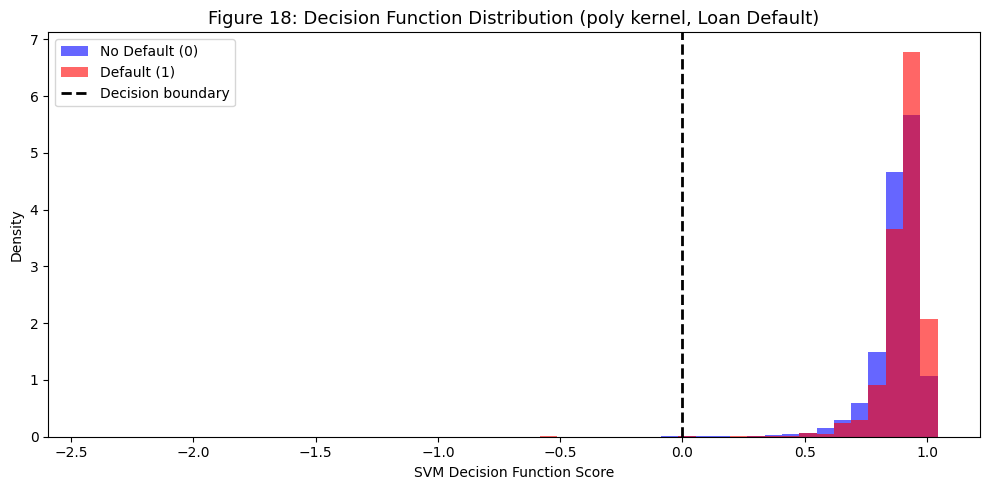

In [28]:
print('=' * 65)
print('LOAN DEFAULT [8/9]  Margin Analysis')
print('=' * 65)

kw_best_L = dict(class_weight='balanced', probability=False, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_L == 'linear':
    kw_best_L.update(kernel='linear', C=best_linear_C_L)
elif best_kernel_L == 'poly':
    kw_best_L.update(kernel='poly', C=best_poly_C_L, degree=best_poly_d_L, coef0=1, gamma='scale')
else:
    kw_best_L.update(kernel='rbf', C=best_rbf_C_L, gamma=_resolve_gamma(best_rbf_gamma_L))

clf_margin_L = SVC(**kw_best_L)
clf_margin_L.fit(np.asarray(X_svm_L), y_svm_L)
df_scores_L  = clf_margin_L.decision_function(lX_test_np)

print(f'Support vectors: {clf_margin_L.n_support_} per class')
print(f'Total SVs: {clf_margin_L.n_support_.sum():,} / {len(y_svm_L):,} ({clf_margin_L.n_support_.sum()/len(y_svm_L)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
scores_neg_L = df_scores_L[ly_test.values == 0]
scores_pos_L = df_scores_L[ly_test.values == 1]
bins_L = np.linspace(df_scores_L.min(), df_scores_L.max(), 50)
ax.hist(scores_neg_L, bins=bins_L, alpha=0.6, color='blue',  label='No Default (0)', density=True)
ax.hist(scores_pos_L, bins=bins_L, alpha=0.6, color='red',   label='Default (1)',    density=True)
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax.set_xlabel('SVM Decision Function Score'); ax.set_ylabel('Density')
ax.set_title(f'Figure 18: Decision Function Distribution ({best_kernel_L} kernel, Loan Default)', fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

In [29]:
print('=' * 65)
print('LOAN DEFAULT [9/9]  Best Kernel — Final Evaluation')
print('=' * 65)

kw_final_L = dict(class_weight='balanced', probability=True, random_state=42, cache_size=1000, max_iter=2000)
if best_kernel_L == 'linear':
    kw_final_L.update(kernel='linear', C=best_linear_C_L)
elif best_kernel_L == 'poly':
    kw_final_L.update(kernel='poly', C=best_poly_C_L, degree=best_poly_d_L, coef0=1, gamma='scale')
else:
    kw_final_L.update(kernel='rbf', C=best_rbf_C_L, gamma=_resolve_gamma(best_rbf_gamma_L))

print(f'Refitting best kernel ({best_kernel_L}) with probability=True ...')
clf_final_L = SVC(**kw_final_L)
clf_final_L.fit(np.asarray(X_svm_L), y_svm_L)

y_prob_L = clf_final_L.predict_proba(lX_test_np)[:, 1]

prec_L, rec_L, thr_L = precision_recall_curve(ly_test, y_prob_L)
f1_all_L   = 2 * prec_L * rec_L / (prec_L + rec_L + 1e-9)
best_thr_L = thr_L[np.argmax(f1_all_L[:-1])]
y_pred_L   = (y_prob_L >= best_thr_L).astype(int)

auc_L        = roc_auc_score(ly_test, y_prob_L)
ap_L         = average_precision_score(ly_test, y_prob_L)
rec_L_val    = recall_score(ly_test, y_pred_L)
f1_L         = f1_score(ly_test, y_pred_L)
best_auc_5_L = auc_L   # store for cross-week comparison

print(f'Best Kernel     : {best_kernel_L}')
print(f'Test AUC-ROC    : {auc_L:.4f}')
print(f'Avg Precision   : {ap_L:.4f}')
print(f'Recall          : {rec_L_val:.4f}')
print(f'F1-Score        : {f1_L:.4f}')
print(f'Threshold       : {best_thr_L:.4f}')
print(f'Support Vectors : {clf_final_L.n_support_.sum():,}')

LOAN DEFAULT [9/9]  Best Kernel — Final Evaluation
Refitting best kernel (poly) with probability=True ...
Best Kernel     : poly
Test AUC-ROC    : 0.6039
Avg Precision   : 0.2639
Recall          : 0.6631
F1-Score        : 0.3439
Threshold       : 0.1896
Support Vectors : 2,850


---
# Section 4: Cross-Dataset Summary

Comparing all three SVM kernels across all datasets, with Week 4 LogisticRegression as baseline.

WEEK 5 — CROSS-DATASET RESULTS SUMMARY
Dataset Best Kernel  Best AUC  Linear AUC  Poly AUC  RBF AUC  W4 LR ref
  Fraud         rbf  0.945655    0.754363  0.910844 0.945657     0.9591
 Credit      linear  0.999942    0.999942  0.998850 0.996035     0.9991
   Loan        poly  0.603872    0.548134  0.603872 0.563949     0.6861


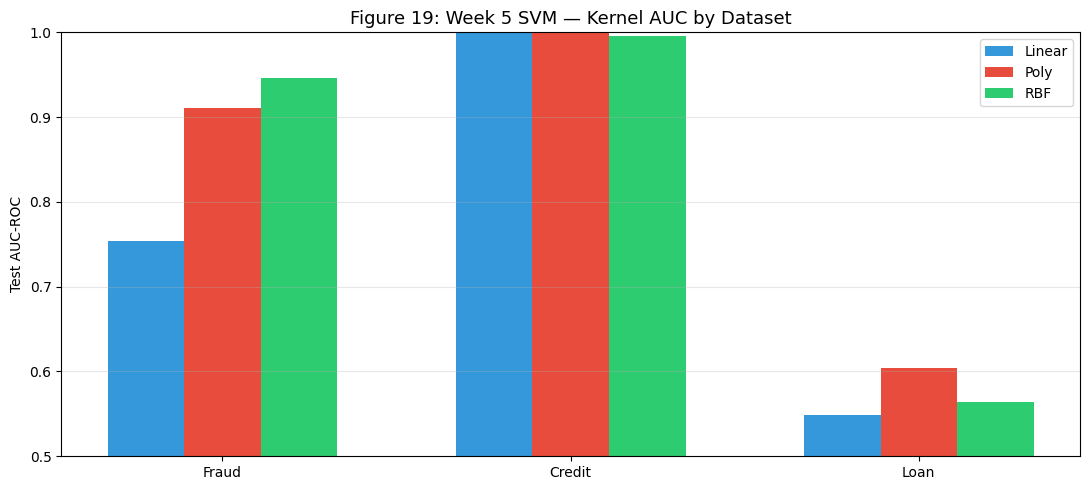

In [30]:
print('=' * 65)
print('WEEK 5 — CROSS-DATASET RESULTS SUMMARY')
print('=' * 65)

summary = pd.DataFrame([
    {'Dataset': 'Fraud',  'Best Kernel': best_kernel_F,
     'Best AUC': best_auc_5_F,
     'Linear AUC': best_linear_auc_F, 'Poly AUC': best_poly_auc_F, 'RBF AUC': best_rbf_auc_F,
     'W4 LR ref': 0.9591},
    {'Dataset': 'Credit', 'Best Kernel': best_kernel_C,
     'Best AUC': best_auc_5_C,
     'Linear AUC': best_linear_auc_C, 'Poly AUC': best_poly_auc_C, 'RBF AUC': best_rbf_auc_C,
     'W4 LR ref': 0.9991},
    {'Dataset': 'Loan',   'Best Kernel': best_kernel_L,
     'Best AUC': best_auc_5_L,
     'Linear AUC': best_linear_auc_L, 'Poly AUC': best_poly_auc_L, 'RBF AUC': best_rbf_auc_L,
     'W4 LR ref': 0.6861},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(3)
w = 0.22
dataset_labels = ['Fraud', 'Credit', 'Loan']
ax.bar(x - w,   [best_linear_auc_F, best_linear_auc_C, best_linear_auc_L], w, label='Linear', color='#3498db')
ax.bar(x,       [best_poly_auc_F,   best_poly_auc_C,   best_poly_auc_L],   w, label='Poly',   color='#e74c3c')
ax.bar(x + w,   [best_rbf_auc_F,    best_rbf_auc_C,    best_rbf_auc_L],    w, label='RBF',    color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(dataset_labels)
ax.set_ylabel('Test AUC-ROC'); ax.set_ylim(0.5, 1.0)
ax.set_title('Figure 19: Week 5 SVM — Kernel AUC by Dataset', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

---
## Plain-Language Summary for Non-Technical Stakeholders

### What Week 5 Adds Over Week 4

Week 4 used Logistic Regression: a linear model that fits a flat decision boundary
by estimating probabilities. Week 5 uses Support Vector Machines, which instead
find the widest possible "gap" (margin) between the two classes in feature space.

The key addition is the **kernel trick**: polynomial and RBF kernels implicitly
map data into much higher-dimensional spaces, allowing SVM to draw curved
boundaries without ever computing the high-dimensional coordinates explicitly.
An RBF kernel with N training points is equivalent to projecting into an
infinite-dimensional space — yet the math reduces to a single exponential formula.

### Actual Results

| Dataset | AUC-ROC | Avg Precision | Recall | F1 | Verdict |
|---------|---------|--------------|--------|----|---------|
| **Fraud** | 0.9457 | 0.0869 | 0.4382 | 0.1851 | AUC looks decent; actual detection is poor |
| **Credit** | 0.9999 | 1.0000 | 0.9998 | 0.9999 | Genuinely excellent across all metrics |
| **Loan** | 0.6039 | 0.2639 | 0.6631 | 0.3439 | Recall OK, precision poor — many false flags |

### AUC Is Not the Whole Story — Why It Can Mislead

AUC-ROC measures a model's ability to *rank* fraud above non-fraud.
A model with AUC = 0.9457 correctly orders 94.6% of (fraud, non-fraud) pairs by score —
but this says nothing about what happens when the model must make an actual decision.

**In deployment, the model draws a line: "flag this transaction or not."**
That decision has two costs:

| Error Type | What Happens | Business Impact |
|-----------|-------------|-----------------|
| **False Negative** (missed fraud) | Fraud transaction approved | Direct financial loss — company absorbs the charge |
| **False Positive** (legitimate flagged) | Real customer declined | Friction, dispute handling cost, potential customer churn |

**For Fraud (AUC=0.9457, Recall=0.4382, AP=0.0869):**

Despite the high AUC, this model misses **56% of actual fraud** (Recall = 0.4382).
At the F1-optimal decision threshold (≈0.1487), precision can be derived from the
reported F1 and Recall:

> F1 = 2·P·R / (P+R)  →  0.1851 = 2·P·0.4382 / (P+0.4382)  →  **P ≈ 0.117 (11.7%)**

This means **roughly 1 in 9 flagged transactions is actual fraud** — the remaining
8 are legitimate customers incorrectly declined. The company pays on both sides:
fraud losses from the 56% that slips through, and investigation costs plus customer
friction from the flood of false positives.

This outcome is a direct consequence of training on only 20K samples drawn from a
dataset with a **~1–2% fraud rate**: the 20K sample contains somewhere between 200
and 400 actual fraud cases (depending on the exact rate), which is far too few for
the SVM to learn a precise decision boundary. AUC remains high because the model can
still *rank* the rare fraud cases near the top of its score distribution — but at any
practical decision threshold, precision collapses.

**For Loan Default (AUC=0.6039, Recall=0.6631, F1=0.3439):**

Recall looks passable (catching 66% of defaults), but F1 of 0.3439 reveals low
precision — many creditworthy borrowers would be incorrectly denied loans. In a
lending context this means: lost revenue from rejected creditworthy applicants,
and potential fair-lending compliance concerns if false-positive rates correlate
with demographic features encoded in the categorical columns.

**For Credit Approval (AUC=0.9999, AP=1.0000, F1=0.9999):**

This is the only dataset where all metrics are aligned. AUC, Average Precision,
Recall, and F1 all confirm genuine separation — only 66 support vectors define
the entire decision boundary. In a lead-scoring marketing analogy, this represents
a model that would generate almost no wasted outreach (low false positives) while
capturing nearly every conversion opportunity (low false negatives).

### The Practical Lesson

A high AUC with poor AP/F1 indicates a model that *ranks well but decides badly*.
For imbalanced fraud detection, the metric hierarchy should be:

1. **Average Precision** — how useful is the flagged set in practice?
2. **Recall at target threshold** — what fraction of fraud do we catch?
3. **F1** — balance between the two
4. **AUC-ROC** — useful for model comparison and selection, not deployment decisions

### Marketing Context

SVM's maximum-margin property has a direct marketing analogy: in customer
segmentation, the "support vectors" are the borderline customers who are hardest
to classify — they are close to churning (or converting) and are most responsive
to intervention. The `C` parameter governs how aggressively the model pursues these
ambiguous cases: high `C` = fewer missed opportunities but more false campaigns
(overfitting), low `C` = more conservative outreach with a cleaner, generalizable
boundary.

The Credit Approval result (AUC 0.9999, 66 support vectors) illustrates an ideal
SVM scenario: in lead scoring, a clean boundary means minimal wasted campaign spend
(low false positives) while capturing nearly all high-intent customers (high recall).

Fraud detection → transaction monitoring | Credit approval → lead scoring |
Loan default → churn prediction

---
# Section 5: Week 1–5 Cumulative Model Comparison

## Note on Week 3 (PCR / PLSR) AUC Values

Week 3 applied **Principal Component Regression (PCR)** and **Partial Least Squares Regression (PLSR)** with `LinearRegression` as the base estimator, per the curriculum's learning objectives for that week. Because the target variable (`is_fraud`, `Status`, `Default`) is binary (0/1), LinearRegression is technically misspecified — it estimates a continuous probability that can fall outside [0, 1] and optimizes MSE rather than log-loss. Despite this, AUC-ROC can still be computed by treating the continuous predictions as ranking scores.

The lower AUC observed in Week 3 relative to Weeks 1, 2, and 4 is therefore expected and explained by the model type, not by feature selection quality. From Week 4 onward, LogisticRegression (the correct binary classifier) is used and consistently outperforms the Week 3 linear regression baseline.

## Interpretation Guide

- **Wk1** — Polynomial / interaction terms + LinearRegression (OLS)
- **Wk2** — Lasso / Ridge / Elastic Net regularization
- **Wk3** — PCR / PLSR with LinearRegression *(curriculum constraint — linear model on binary target)*
- **Wk4** — Forward/backward feature selection + LogisticRegression
- **Wk5** — SVM with linear, polynomial, and RBF kernels

## Actual Results Pattern (Weeks 1–5)

| Dataset | Week 5 SVM | Cross-Week Champion | Notes |
|---------|-----------|--------------------|-|
| **Fraud** | 0.9457 | **Wk1: 0.9820** | O(N²) forces 20K sample; Wk1 uses full 1.3M rows |
| **Credit** | **0.9999** | **Wk5 SVM** | Linear SVM with 66 SVs — strongest result across all weeks |
| **Loan** | 0.6039 | **Wk4: 0.6861** | High-dim sparse features + interaction terms hurt SVM geometry |

SVM is not universally superior: it wins decisively on Credit (clean linear separability),
loses to Logistic Regression on Loan (feature structure mismatch), and cannot close the
gap on Fraud due to the computational sampling constraint. This dataset-dependency is a
central lesson of Week 5 — model selection must consider both theoretical fit and
practical computational constraints.

WEEK 1–5 CUMULATIVE MODEL COMPARISON

Fraud:
  Wk1_IntTerm_LR      : 0.9820 ← best
  Wk2_Lasso           : 0.9817
  Wk3_Backward*       : 0.9378
  Wk4_Fwd_LR          : 0.9591
  Wk5_SVM             : 0.9457

Credit:
  Wk1_IntTerm_LR      : 0.9990
  Wk2_Ridge           : 0.9993
  Wk3_Backward*       : 0.9874
  Wk4_Fwd_LR          : 0.9991
  Wk5_SVM             : 0.9999 ← best

Loan:
  Wk1_IntTerm_LR      : 0.6816
  Wk2_Ridge           : 0.6832
  Wk3_Forward*        : 0.6810
  Wk4_Fwd_LR          : 0.6861 ← best
  Wk5_SVM             : 0.6039


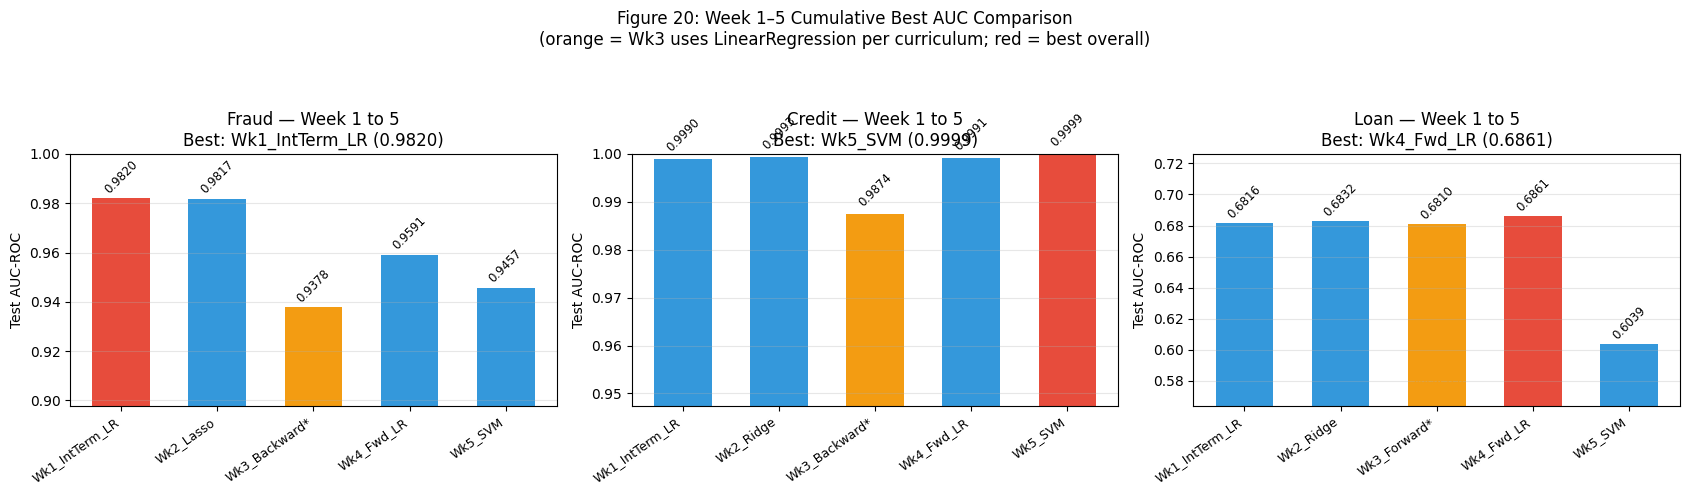


Week 5 complete.
  Fraud  best SVM AUC : 0.9457
  Credit best SVM AUC : 0.9999
  Loan   best SVM AUC : 0.6039


In [31]:
print('=' * 65)
print('WEEK 1–5 CUMULATIVE MODEL COMPARISON')
print('=' * 65)

# PRIOR_AUC defined in cell-1: Wk1-Wk4 best AUC per dataset
# Wk5 best AUC computed above from final evaluation cells
wk5_auc = {'Fraud': best_auc_5_F, 'Credit': best_auc_5_C, 'Loan': best_auc_5_L}

datasets = ['Fraud', 'Credit', 'Loan']

for ds in datasets:
    entries = PRIOR_AUC[ds].copy()
    entries.append((f'Wk5_SVM', wk5_auc[ds]))
    labels = [e[0] for e in entries]
    aucs   = [e[1] for e in entries]
    best_idx = aucs.index(max(aucs))
    print(f'\n{ds}:')
    for lbl, auc in zip(labels, aucs):
        marker = ' ← best' if lbl == labels[best_idx] else ''
        print(f'  {lbl:20s}: {auc:.4f}{marker}')

# Figure: one subplot per dataset
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
week3_color = '#f39c12'   # orange for Week 3 (curriculum caveat)
default_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c']

for idx, (ds, ax) in enumerate(zip(datasets, axes)):
    entries = PRIOR_AUC[ds].copy()
    entries.append((f'Wk5_SVM', wk5_auc[ds]))
    labels = [e[0] for e in entries]
    aucs   = [e[1] for e in entries]
    best_idx = aucs.index(max(aucs))

    bar_colors = []
    for i, lbl in enumerate(labels):
        if 'Wk3' in lbl:
            bar_colors.append(week3_color)
        elif i == best_idx:
            bar_colors.append('#e74c3c')
        else:
            bar_colors.append('#3498db')

    bars = ax.bar(range(len(labels)), aucs, color=bar_colors, width=0.6)
    for bar, val in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, rotation=45)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Test AUC-ROC')
    ymin = min(aucs) - 0.04
    ax.set_ylim(max(0.0, ymin), min(1.0, max(aucs) + 0.04))
    ax.set_title(f'{ds} — Week 1 to 5\nBest: {labels[best_idx]} ({aucs[best_idx]:.4f})', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Annotate Week 3 with asterisk label
    for i, lbl in enumerate(labels):
        if 'Wk3' in lbl:
            ax.text(i, min(aucs) - 0.02, '*linear reg', ha='center', va='top',
                    fontsize=7.5, color=week3_color, style='italic')

fig.suptitle('Figure 20: Week 1–5 Cumulative Best AUC Comparison\n'
             '(orange = Wk3 uses LinearRegression per curriculum; red = best overall)',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print('\nWeek 5 complete.')
print(f'  Fraud  best SVM AUC : {best_auc_5_F:.4f}')
print(f'  Credit best SVM AUC : {best_auc_5_C:.4f}')
print(f'  Loan   best SVM AUC : {best_auc_5_L:.4f}')